# 《微信红包“手气最佳接龙”的机制分析与最优参与策略研究》

## 一、摘要
本研究以微信红包“手气最佳接龙”为研究对象，通过实验数据收集、统计分析与数学建模，系统探究了其随机分配机制与参与者行为规律。实验在8人微信群中进行500轮红包发放（总金额40元/轮），记录并分析“手气最佳”的分布特征。研究结果表明，手气最佳金额呈现右偏分布，且与参与顺序无明显相关性。基于此，本文提出了基于概率期望与风险偏好的最优参与策略模型，为参与者在实际接龙游戏中提供理论依据与策略建议。

## 二、关键词
微信红包、手气最佳接龙、随机分配、机制分析、最优策略、概率模型

## 三、引言

    微信红包作为中国社交网络中的一种重要互动形式，其“手气最佳接龙”玩法在各类群聊中广泛流行。该玩法通常由一名发起者发放固定金额的红包，参与者随机领取，金额最高者（即“手气最佳”）成为下一轮红包的发起者。尽管该过程看似完全随机，但参与者普遍关心是否存在“最佳领取时机”或“策略性参与”的可能。
    目前，关于微信红包分配机制的研究多集中于普通红包的随机算法（如二倍均值法），而对于“手气最佳接龙”这一特殊玩法的系统性分析仍较为缺乏。此外，参与者在连续多轮游戏中的行为策略、风险偏好与长期收益之间的关系也尚未得到深入探讨。
    本研究旨在通过实证数据与理论建模相结合的方式，揭示“手气最佳接龙”的内在机制，并构建参与者的最优策略模型。研究结果不仅有助于理解群体互动中的随机分配行为，也为参与者在实际游戏中的决策提供科学参考。

## 四、研究过程

### （一）微信红包机制分析

#### 1、数据统计

##### 1.1 数据收集

我们共进行了三次数据收集，均使用在微信群聊中发送“拼手气红包”的模式。对于每组数据，我们控制所有红包的**单个红包总额相同**、**参与人数相同**、**抢红包顺序随机**，三个数据集的具体对比如下：
| 数据集 | 数据集A | 数据集B | 数据集C |
|-------|-------|-------|-------|
| 采集时间 | 12.25 | 1.15 | 1.16 |
| 单个红包总额 | 60 | 15 | 40 |
| 参与人数 | 15 | 3 | 8 |
| 红包总数 | 150 | 60 | 480 |

其中，**数据集A**和**数据集B**由于样本量较小，不具有显著的统计学意义，我们仅将其作为验证集，后续的数据处理和分析主要围绕**数据集C**展开。三个数据集的原始数据均存储在目录`\data`下。

##### 1.2 数据处理与可视化

我们对所收集到的数据进行处理，得到以下图以及数据：

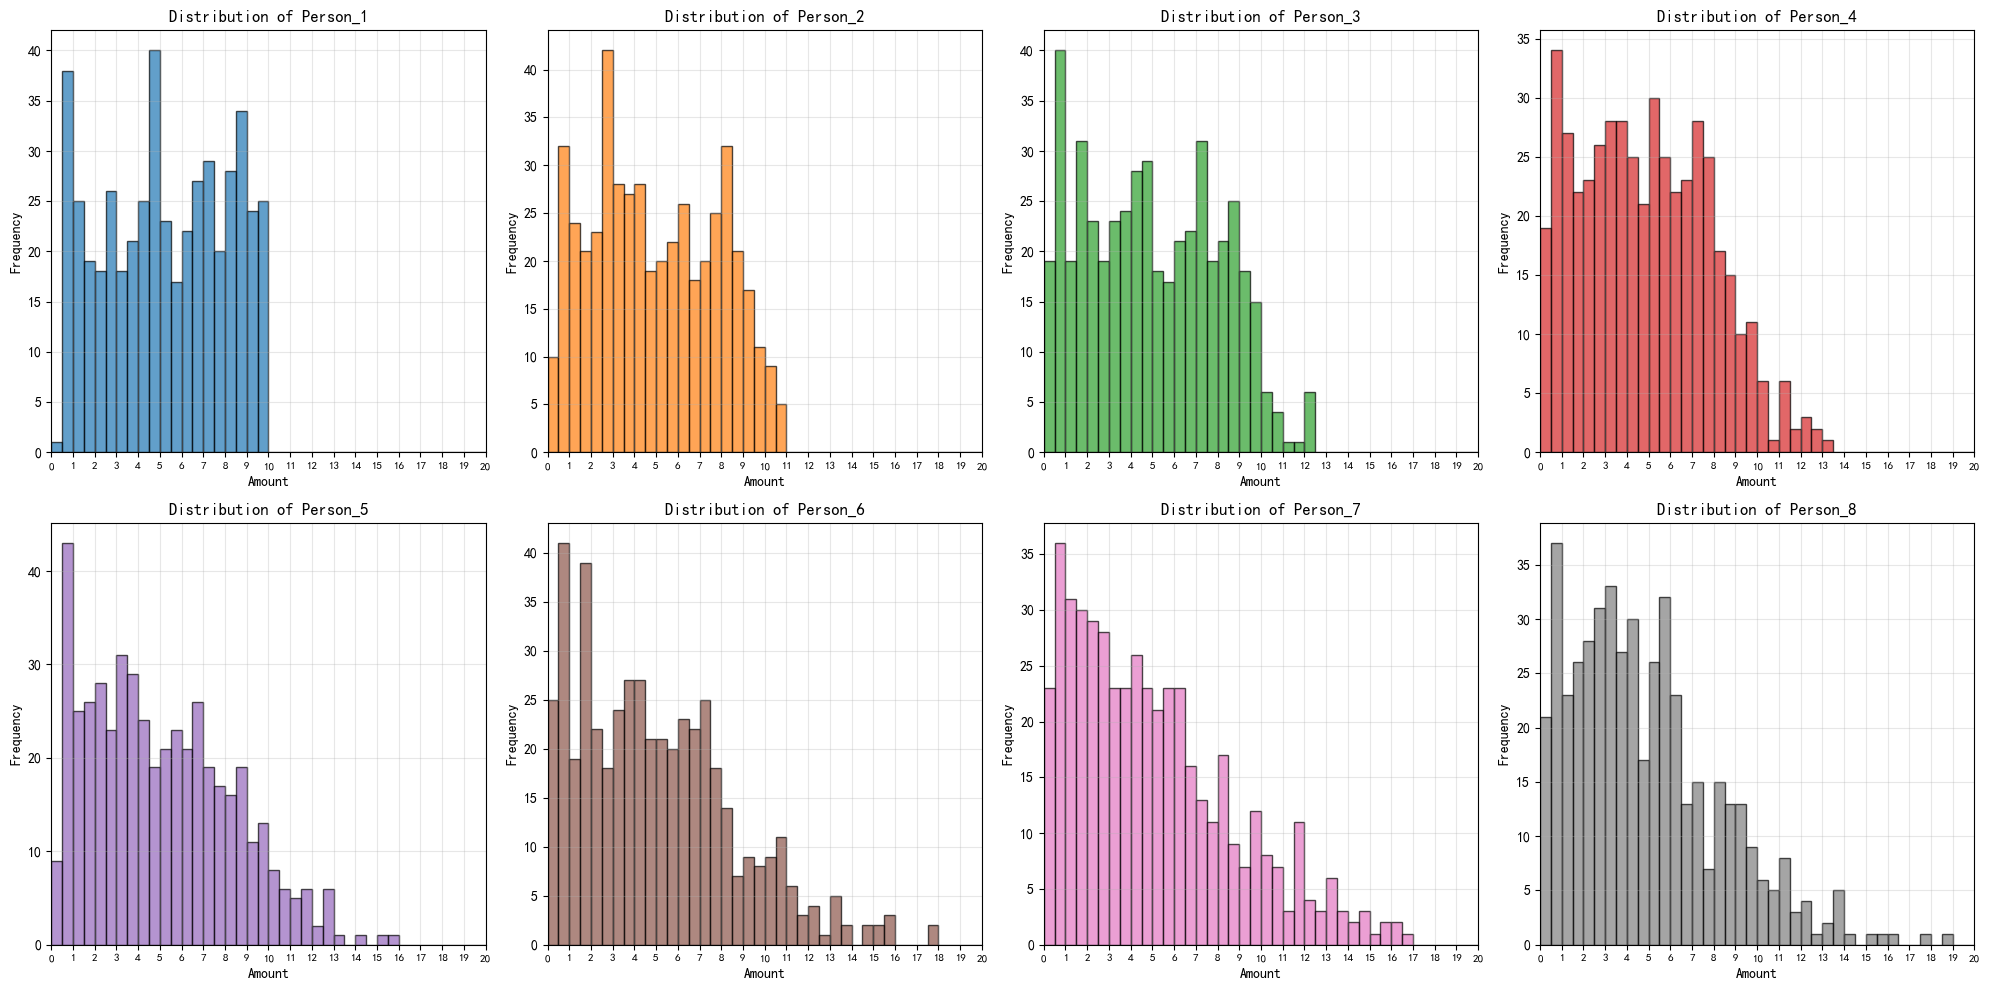

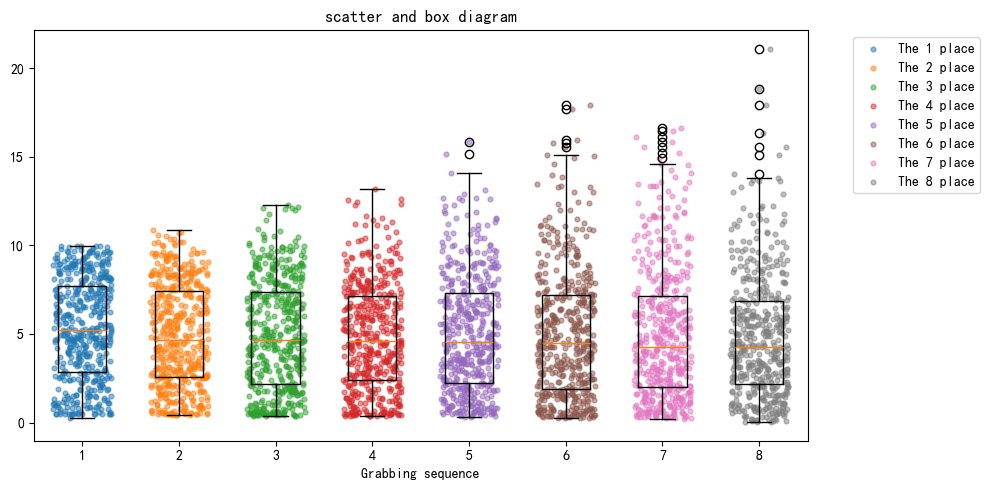

Number of trials: 480
Number of people: 8
Total amount per trial: 40.0

Summary statistics:
         Person_1    Person_2    Person_3    Person_4    Person_5    Person_6  \
count  480.000000  480.000000  480.000000  480.000000  480.000000  480.000000   
mean     5.275958    4.931563    4.968271    4.858833    5.033083    5.026937   
std      2.818566    2.851525    3.078108    2.962750    3.255473    3.596694   
min      0.260000    0.440000    0.380000    0.360000    0.300000    0.260000   
25%      2.860000    2.587500    2.165000    2.425000    2.247500    1.910000   
50%      5.220000    4.670000    4.690000    4.590000    4.530000    4.475000   
75%      7.697500    7.455000    7.402500    7.147500    7.327500    7.230000   
max      9.980000   10.860000   12.280000   13.190000   15.820000   17.920000   

         Person_7    Person_8  
count  480.000000  480.000000  
mean     5.024500    4.880854  
std      3.710216    3.510164  
min      0.230000    0.040000  
25%      2.027500 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV数据
path = "data/real_480.csv"
raw = pd.read_csv(path)

# 获取数据（跳过表头行）
data = raw.iloc[0:].reset_index(drop=True)

# 获取参数
number = data.shape[0]  # 样本数量
people = data.shape[1] - 1  # 参与者数量（去掉第一列Trial）
money = data.iloc[:, 1:].sum(axis=1).iloc[0]  # 每次试验的总金额

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 为数据添加列名
pos_cols = [f"Person_{i+1}" for i in range(people)]
data.columns = ['Trial'] + pos_cols

# 创建图形，8个子图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

# 为每个参与者绘制频数直方图
for i, col in enumerate(pos_cols):
    # 只显示0到10之间的数据，并设置bins
    filtered_data = data[col].astype(float)[data[col].astype(float) <= 20]
    n, bins, patches = axes[i].hist(filtered_data, bins=np.arange(0, 20.1, 0.5), alpha=0.7, color=f'C{i}', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Amount')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # 设置横坐标范围和刻度
    axes[i].set_xlim(0, 20)
    axes[i].set_xticks(np.arange(0, 20.1, 1))  # 每1个单位一个刻度
    axes[i].tick_params(axis='x', labelsize=8)  # 减小字体大小以适应更多标签

plt.tight_layout()
plt.show()


# 5. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(10, 5))
plt.boxplot(box_data, showfliers=True)

positions = sorted(long_df["pos_id"].unique())
# 每列宽度（以 x 轴单位计），点在该宽度内均匀分布
col_width = 0.6
# 散点大小（marker area），确保点宽小于列宽
marker_size = 12

for idx, pos in enumerate(positions):
    y = long_df[long_df["pos_id"] == pos]["amount"].values
    n = len(y)
    if n == 0:
        continue
    # 在列范围内均匀随机分布 x，避免集中在同一竖线
    left = pos - col_width / 2 + 1e-6
    right = pos + col_width / 2 - 1e-6
    x = np.random.uniform(left, right, size=n)
    # 仅为第一个位置添加图例，避免重复图例项
    label = f"The {pos} place" 
    plt.scatter(x, y, alpha=0.5, s=marker_size, label=label)

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 打印基本信息
print(f"Number of trials: {number}")
print(f"Number of people: {people}")
print(f"Total amount per trial: {money}")
print("\nSummary statistics:")
print(data[pos_cols].describe())

##### 1.3 数据分析

从采集到的数据中我们不难得到以下结论：
1. 8个人所抢到单个红包的平均金额相近，约等于单个红包的总金额/人数（$40*2/8=10$）。
其中最大误差发生在第一位的。根据对于原始数据的进一步分析，我们发现，第一位所抢到的金额没有小于0.5元的，且出现抢到0.5元的概率远远大于其他金额，因此我们怀疑微信存在最小金额保底机制，具体保底金额为红包金额的10%。

2. 8个人所抢到金额的方差差距较大，整体满足先减小后增大的趋势。不过由于数据样本不足，趋势不明显且可能存在误差，因此此结论有待进一步研究。

3. 虽然抢红包的数额为以0.01为分度值的离散量，但样本量足够多时，其分布函数趋于连续，离散随机过程在分布意义下可以用连续模型近似，且不改变结构关系。


#### 2. 模型建立

##### 2.1 模型猜测一：均匀分布

##### 2.1.1 模型描述

出于对于抢红包公平性以及机制简单性的考虑，我们首先考虑使用均匀分布进行建模。

##### 2.1.2 数据拟合
如果假设红包金额服从均匀分布，则其概率密度函数为：

$$ f(x|a,b) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases} $$

其中：

- $a$ 是分布的下界（最低红包金额）
- $b$ 是分布的上界（最高红包金额）





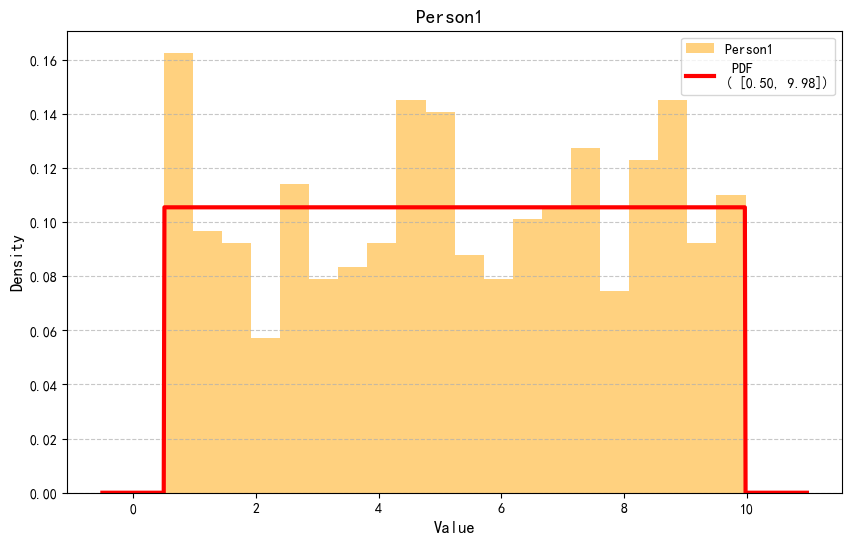

拟合结果：
最小值 (a): 0.5000
最大值 (b): 9.9800
区间长度 (b-a): 9.4800


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!python -m pip install scipy
from scipy.stats import uniform

df = pd.read_csv("最大似然估计和KS检验\\均匀分布估计\\envelopes.csv")



# 2. 数据清洗：剔除最后一行 "Total"
df_clean = df.iloc[:-1].copy()

# 确保 Person1 列为浮点数类型
person1_values = df_clean['Person1'].astype(float)

# 3. 使用均匀分布拟合数据
# uniform.fit 返回 (loc, scale)，其中 loc 是起点 a，scale 是区间长度 (b - a)
a_fit, scale_fit = uniform.fit(person1_values)
b_fit = a_fit + scale_fit

# 4. 绘图
plt.figure(figsize=(10, 6))

# 绘制直方图（density=True 保证纵坐标为概率密度）
plt.hist(person1_values, bins=20, density=True, alpha=0.5, color='orange', label='Person1 ')

# 生成拟合的 PDF 曲线
x = np.linspace(a_fit - 1, b_fit + 1, 1000)
pdf = uniform.pdf(x, loc=a_fit, scale=scale_fit)
plt.plot(x, pdf, 'r-', lw=3, label=f' PDF\n( [{a_fit:.2f}, {b_fit:.2f}])')

# 设置图表细节
plt.title('Person1 ', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 输出拟合参数
print(f"拟合结果：")
print(f"最小值 (a): {a_fit:.4f}")
print(f"最大值 (b): {b_fit:.4f}")
print(f"区间长度 (b-a): {scale_fit:.4f}")


最终的拟合结果可以表示为：

$$ X_1 \sim Uniform(0.5, 9.98) $$


##### 2.1.3 KS 检验

Executing Monte Carlo Simulation (5000 iterations)...


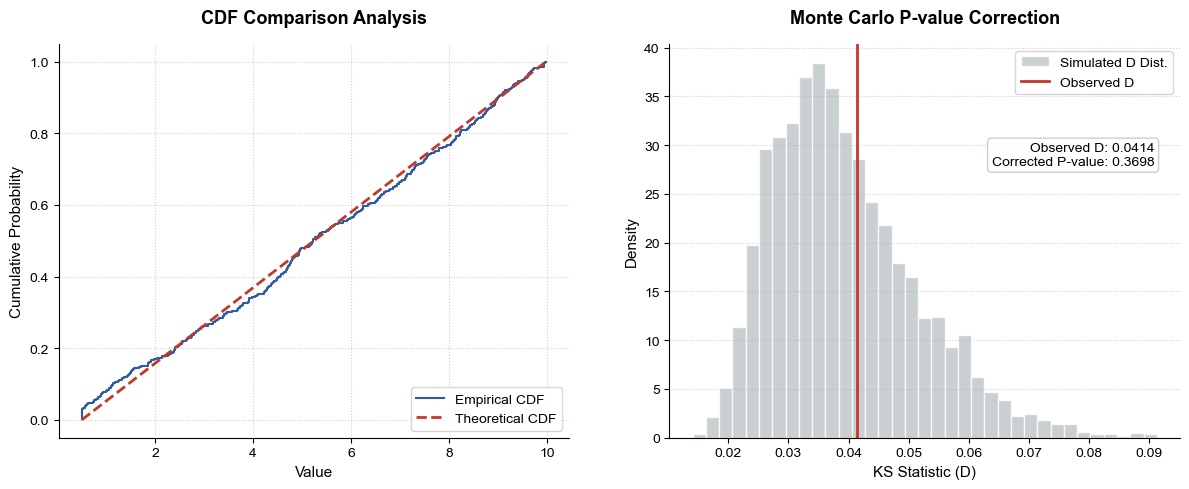

Fit Results: a=0.500, b=9.980
Corrected P-value: 0.3698


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, kstest
import io

# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person1'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

得到的P > 0.5，接受均匀分布模型和参数，$X_1$满足均匀分布。

然而，我们发现：后续几个人领到的金额出现了明显的拖尾效应。在散点图上可以观察到后面几个人的样本明显向更大的金额上扩散，且尾端分布呈现出递减的形状。此时继续用均匀分布模型明显不再合适，比如我们分析第三个人的样本：

Executing Monte Carlo Simulation (5000 iterations)...


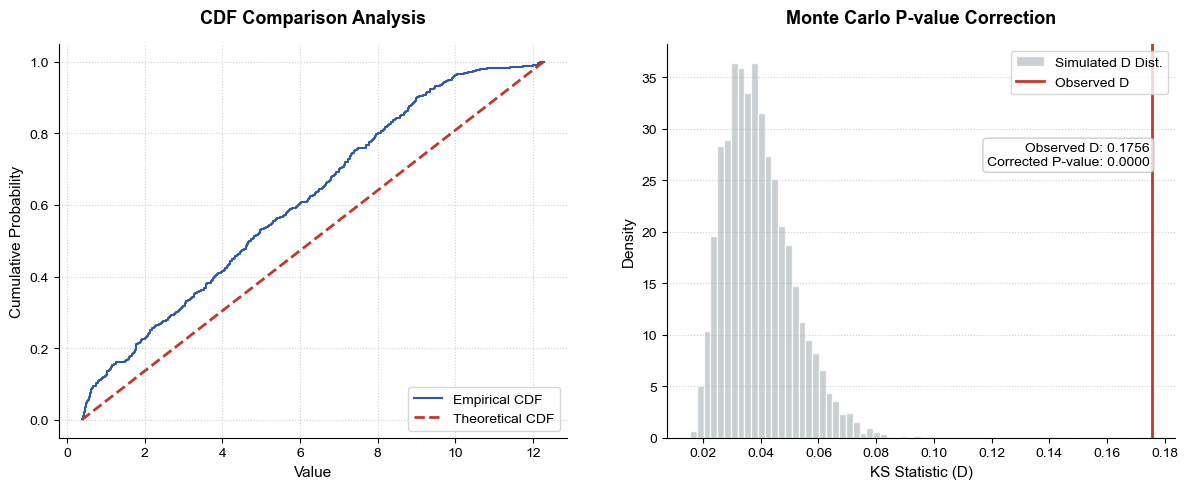

Fit Results: a=0.380, b=12.280
Corrected P-value: 0.0000


In [9]:
# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person3'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.1.4 结论
$X_1$服从均匀分布，$X_i$(i>1)不服从均匀分布

#### 2.2 猜测模型二：正态分布

##### 2.2.1 模型描述

考虑到样本直方图尾部的递减形状和正态分布相似，以及正态分布的普遍性，我们再尝试用正态分布解释$X_i$(i>1)。

##### 2.2.2 数据拟合&检验

Executing Monte Carlo Simulation for Person3...


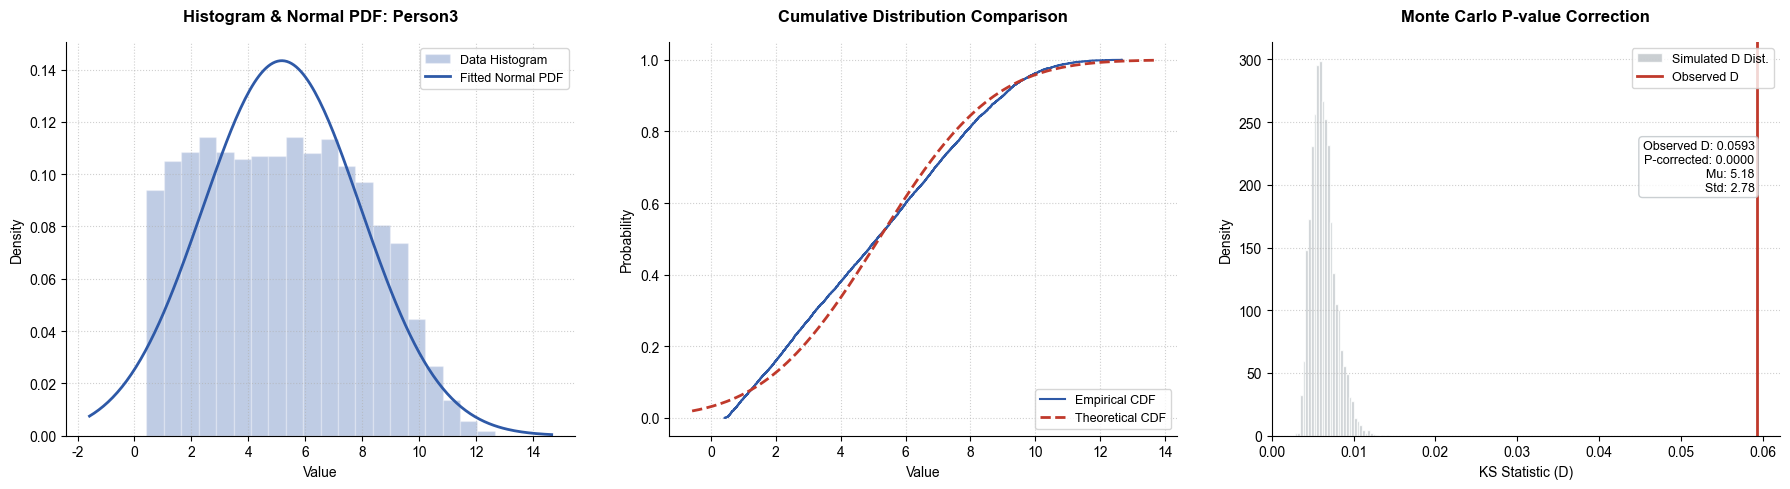

Results for Person3:
Normal Parameters: Mu=5.180, Std=2.782
KS Statistic D:    0.0593
Corrected P-value: 0.0000


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest
import io
df = pd.read_csv('envelopes.csv')
# 1. 数据准备
# 剔除最后一行 "Total"
df_clean = df[df['Trial'] != 'Total'].copy()

# 选择目标数据（这里以 Person1 为例）
target_person = 'Person3' 
data_values = df_clean[target_person].astype(float).values
n_samples = len(data_values)

# 2. 参数估计与 KS 统计量计算
mu_obs, std_obs = norm.fit(data_values)
d_obs, _ = kstest(data_values, 'norm', args=(mu_obs, std_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation for {target_person}...")
for i in range(n_sims):
    sim_sample = norm.rvs(loc=mu_obs, scale=std_obs, size=n_samples)
    mu_sim, std_sim = norm.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'norm', args=(mu_sim, std_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (调整为三子图，比例 18:5)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 增加画布宽度以容纳三个图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# --- Plot 1: Histogram & PDF ---
# 绘制直方图 (使用较淡的蓝色)
ax1.hist(data_values, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
# 绘制 PDF 曲线 (使用深蓝色)
x_pdf = np.linspace(data_values.min() - 2, data_values.max() + 2, 200)
y_pdf = norm.pdf(x_pdf, mu_obs, std_obs)
ax1.plot(x_pdf, y_pdf, color='#2E59A7', lw=2, label='Fitted Normal PDF')

ax1.set_title(f'Histogram & Normal PDF: {target_person}', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: ECDF vs Normal CDF (配色保持一致) ---
sorted_data = np.sort(data_values)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_cdf = np.linspace(sorted_data.min() - 1, sorted_data.max() + 1, 200)
y_cdf = norm.cdf(x_cdf, loc=mu_obs, scale=std_obs)

ax2.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post')
ax2.plot(x_cdf, y_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2)

ax2.set_title('Cumulative Distribution Comparison', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Value', fontsize=10)
ax2.set_ylabel('Probability', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: D-statistic Rank Analysis (配色保持一致) ---
ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax3.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label='Observed D')

ax3.set_title('Monte Carlo P-value Correction', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('KS Statistic (D)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')

# 标注信息框
text_str = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nMu: {mu_obs:.2f}\nStd: {std_obs:.2f}'
ax3.text(0.95, 0.75, text_str, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax3.legend(loc='upper right', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)
plt.show()

# 控制台结果
print(f"Results for {target_person}:")
print(f"Normal Parameters: Mu={mu_obs:.3f}, Std={std_obs:.3f}")
print(f"KS Statistic D:    {d_obs:.4f}")
print(f"Corrected P-value: {p_corrected:.4f}")

Using a random subset of 5000 samples.
Executing Monte Carlo Simulation for Person3...


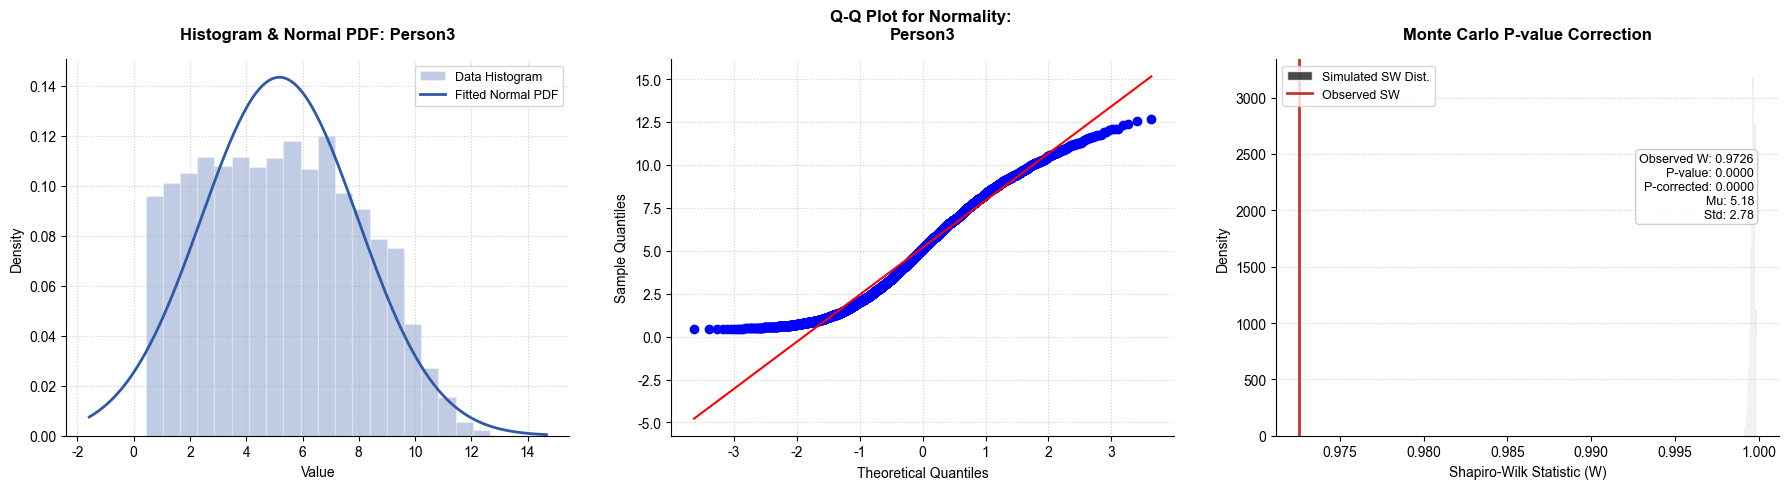

Results for Person3:
Normal Parameters: Mu=5.180, Std=2.782
SW Statistic W:    0.9726
Original P-value:  0.0000
Corrected P-value: 0.0000


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
import io

df = pd.read_csv('envelopes.csv')
# 1. 数据准备
# 剔除最后一行 "Total"
df_clean = df[df['Trial'] != 'Total'].copy()

# 选择目标数据（这里以 Person1 为例）
target_person = 'Person3' 
data_values = df_clean[target_person].astype(float).values
n_samples = len(data_values)

# 2. 参数估计与 Shapiro-Wilk 统计量计算
mu_obs, std_obs = norm.fit(data_values)
# 注意：Shapiro-Wilk 检验有样本量限制，最大为 5000
if n_samples > 5000:
    print(f"Warning: Sample size ({n_samples}) exceeds Shapiro-Wilk limit of 5000.")
    print("Using a random subset of 5000 samples.")
    np.random.seed(42)  # 为了可重复性
    data_values = np.random.choice(data_values, size=5000, replace=False)
    n_samples = len(data_values)

sw_obs, p_obs = shapiro(data_values)

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
sw_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation for {target_person}...")
for i in range(n_sims):
    sim_sample = norm.rvs(loc=mu_obs, scale=std_obs, size=n_samples)
    sw_sim, _ = shapiro(sim_sample)
    sw_sims[i] = sw_sim

p_corrected = np.mean(sw_sims <= sw_obs)

# 4. 绘图 (调整为三子图，比例 18:5)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 增加画布宽度以容纳三个图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# --- Plot 1: Histogram & PDF ---
# 绘制直方图 (使用较淡的蓝色)
ax1.hist(data_values, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
# 绘制 PDF 曲线 (使用深蓝色)
x_pdf = np.linspace(data_values.min() - 2, data_values.max() + 2, 200)
y_pdf = norm.pdf(x_pdf, mu_obs, std_obs)
ax1.plot(x_pdf, y_pdf, color='#2E59A7', lw=2, label='Fitted Normal PDF')

ax1.set_title(f'Histogram & Normal PDF: {target_person}', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: Quantile-Quantile Plot (代替CDF比较，更适合SW检验) ---
from scipy.stats import probplot
probplot(data_values, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot for Normality: \n' + target_person, fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Theoretical Quantiles', fontsize=10)
ax2.set_ylabel('Sample Quantiles', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: SW-statistic Analysis (替换为SW检验统计量) ---
# 限制x轴范围为模拟统计量的合理区间
x_min, x_max = np.percentile(sw_sims, 1), np.percentile(sw_sims, 99)
ax3.hist(sw_sims, bins=35, color="#1a1a1a", edgecolor='white', alpha=0.8, density=True, 
         label='Simulated SW Dist.', range=(x_min, x_max))  # 更深的灰色
ax3.axvline(sw_obs, color='#C0392B', linestyle='-', linewidth=2, label='Observed SW')

ax3.set_title('Monte Carlo P-value Correction', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('Shapiro-Wilk Statistic (W)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')

# 标注信息框
text_str = f'Observed W: {sw_obs:.4f}\nP-value: {p_obs:.4f}\nP-corrected: {p_corrected:.4f}\nMu: {mu_obs:.2f}\nStd: {std_obs:.2f}'
ax3.text(0.95, 0.75, text_str, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax3.legend(loc='upper left', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)
plt.show()

# 控制台结果
print(f"Results for {target_person}:")
print(f"Normal Parameters: Mu={mu_obs:.3f}, Std={std_obs:.3f}")
print(f"SW Statistic W:    {sw_obs:.4f}")
print(f"Original P-value:  {p_obs:.4f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.2.3 结论
可以发现P值依旧很小，说明数据并不符合正态分布

#### 2.3 模型猜测三：分段式模型

##### 2.3.1 模型描述

尝试了其他几种模型后，发现其表现都不尽如人意，考虑到直方图中表现出的头部快速下降，后平稳再下降的趋势，我们决定使用分段混合式模型:
模型由三段组成，第一段为指数衰减段，第二段为均匀分布段，第三段为指数衰减段，具体解析式和参数表示见下：

##### 1. 概率密度函数 $f(x)$

$$
f(x|\theta) = 
\begin{cases} 
k \cdot e^{\lambda_1(\tau_1 - x)} & a \le x < \tau_1 & \text{(第一段：指数衰减)} \\
k & \tau_1 \le x \le \tau_2 & \text{(第二段：均匀平台)} \\
k \cdot e^{-\lambda_2(x - \tau_2)} & \tau_2 < x \le b & \text{(第三段：指数衰减)} \\
0 & \text{其他}
\end{cases}
$$

其中，$k$ 是**归一化常数**（即平台高度），由全概率公理 $\int_a^b f(x)dx = 1$ 确定。

##### 2. 归一化常数 $k$ 的推导

计算三个分段区域的面积：
- **Area 1**: $\int_a^{\tau_1} k e^{\lambda_1(\tau_1 - x)} dx = k \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} \right]$
- **Area 2**: $\int_{\tau_1}^{\tau_2} k dx = k(\tau_2 - \tau_1)$
- **Area 3**: $\int_{\tau_2}^b k e^{-\lambda_2(x - \tau_2)} dx = k \left[ \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]$

令总面积等于 1，解得 $k$：
$$k = \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} + (\tau_2 - \tau_1) + \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]^{-1}$$

##### 3. 累积分布函数 $F(x)$

$$
F(x) = 
\begin{cases} 
k \frac{e^{\lambda_1(\tau_1 - a)} - e^{\lambda_1(\tau_1 - x)}}{\lambda_1} & a \le x < \tau_1 \\
F(\tau_1) + k(x - \tau_1) & \tau_1 \le x \le \tau_2 \\
F(\tau_2) + k \frac{1 - e^{-\lambda_2(x - \tau_2)}}{\lambda_2} & \tau_2 < x \le b
\end{cases}
$$



模型包含以下 4 个待估参数（假设边界 $a, b$ 已知）：

1.  **$\tau_1$ (第一转折点)**：数据从初始衰减进入稳定平台的临界值。
2.  **$\tau_2$ (第二转折点)**：数据从稳定平台进入末端衰减的临界值。要求 $a < \tau_1 < \tau_2 < b$。
3.  **$\lambda_1$ (起始衰减率)**：控制首段下降的陡峭程度。$\lambda_1 > 0$ 时，曲线从左向右下降。
4.  **$\lambda_2$ (末端衰减率)**：控制尾段下降的陡峭程度。$\lambda_2 > 0$ 时，曲线从平台向右下降。

##### 2.3.2 最大似然估计 (MLE) 求解

给定一组独立同分布（i.i.d.）的观测样本 $x = \{x_1, x_2, ..., x_n\}$。

##### 1. 构建似然函数 $L(\theta)$

$$L(\theta) = \prod_{i=1}^{n} f(x_i | \tau_1, \tau_2, \lambda_1, \lambda_2)$$

##### 2. 构建对数似然函数 $\ell(\theta)$

为了简化计算，取对数：
$$\ell(\theta) = \sum_{i=1}^{n} \ln f(x_i)$$

根据 $x_i$ 落在的不同区间进行分类计数：
- 令 $n_1, n_2, n_3$ 分别为落在三个区间的样本数量。
- 展开对数项：
$$\ell(\theta) = n \ln k + \sum_{x_i \in [a, \tau_1)} \lambda_1(\tau_1 - x_i) + \sum_{x_i \in (\tau_2, b]} -\lambda_2(x_i - \tau_2)$$

其中 $k$ 是关于所有 4 个参数的复杂函数。

##### 3. 求解导数（一阶条件）

理论上，我们需要对各参数求偏导并令其为 0：
- $\frac{\partial \ell}{\partial \lambda_1} = 0, \quad \frac{\partial \ell}{\partial \lambda_2} = 0$
- $\frac{\partial \ell}{\partial \tau_1} = 0, \quad \frac{\partial \ell}{\partial \tau_2} = 0$

**注意**：由于 $k$ 的表达式包含指数项且分段点 $\tau$ 出现在求和符号的指示函数中，该方程组没有解析解（Closed-form solution）。

##### 4. 数值优化算法过程

在实际计算中，我们用 `L-BFGS-B` 算法来最大化 $\ell(\theta)$：

1.  **约束条件**：
    *   $a + \epsilon \le \tau_1 \le \tau_2 - \epsilon$
    *   $\tau_1 + \epsilon \le \tau_2 \le b - \epsilon$
    *   $\lambda_1, \lambda_2 > 0$
2.  **目标函数**：最小化负对数似然函数 $-\ell(\theta)$。
3.  **搜索过程**：
    *   算法在四维空间搜索 $(\tau_1, \tau_2, \lambda_1, \lambda_2)$。
    *   每一轮迭代都会根据当前的参数重新计算归一化系数 $k$。
    *   利用梯度下降或拟牛顿法寻找使样本出现概率最大的参数组合。

##### 2.3.3 数据拟合&模型检验

Running Analysis for Person1...


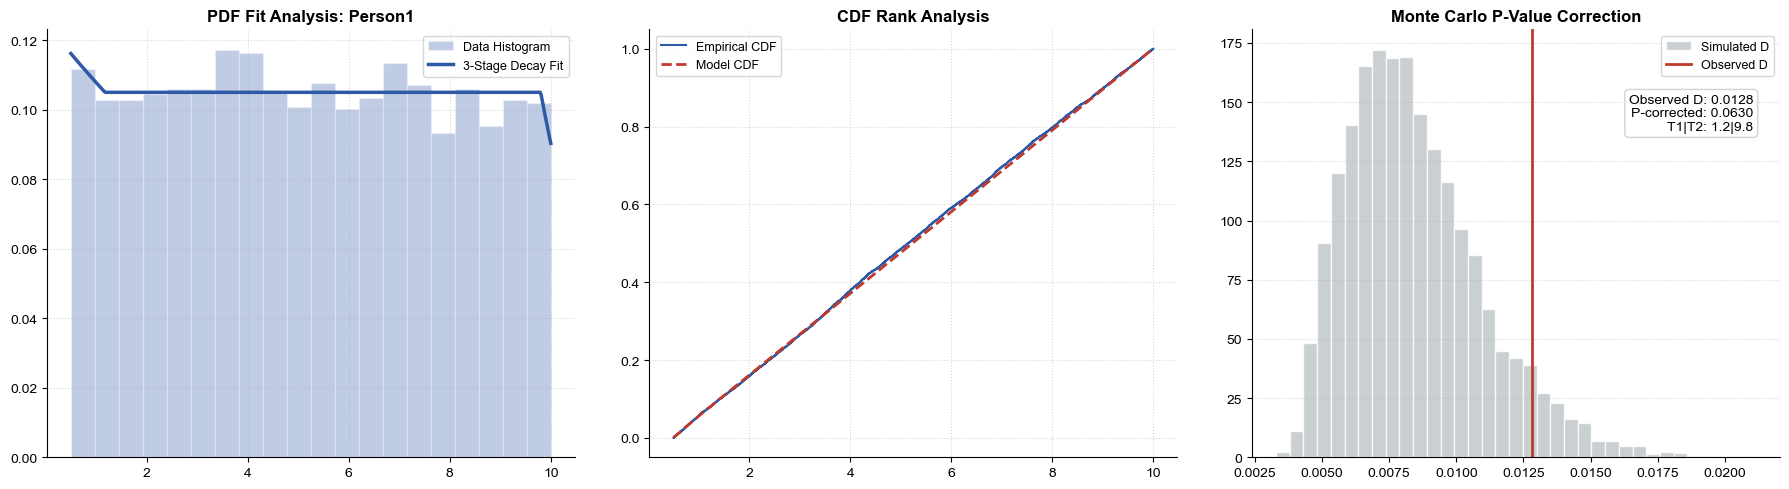

Analysis for Person1 completed. P-corrected: 0.0630


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest
import io
df = pd.read_csv('envelopes.csv')
def analyze_person_distribution(person_num):
    """
    全过程分析函数：拟合三段式(衰减-平台-衰减)分布并进行蒙特卡洛P值修正
    参数 person_num: 整数，对应 Person1, Person2...
    """
    # --- 1. 数据提取与预处理 ---
    target_col = f'Person{person_num}'
    # 假设 df 已经在全局作用域中定义
    df_clean = df[df['Trial'] != 'Total'].copy()
    data = df_clean[target_col].astype(float).values
    n_samples = len(data)
    v_min, v_max = data.min(), data.max()

    # --- 2. 模型核心数学定义 ---
    def get_params(t1, t2, l1, l2, a, b):
        area1 = (np.exp(l1 * (t1 - a)) - 1) / max(l1, 1e-10)
        area2 = t2 - t1
        area3 = (1 - np.exp(-l2 * (b - t2))) / max(l2, 1e-10)
        k = 1.0 / (area1 + area2 + area3)
        p1 = k * area1
        p2 = p1 + k * area2
        return k, p1, p2

    def pdf_func(x, t1, t2, l1, l2, a, b):
        k, _, _ = get_params(t1, t2, l1, l2, a, b)
        pdf = np.zeros_like(x)
        m1, m2, m3 = (x < t1), (x >= t1) & (x <= t2), (x > t2)
        pdf[m1] = k * np.exp(l1 * (t1 - x[m1]))
        pdf[m2] = k
        pdf[m3] = k * np.exp(-l2 * (x[m3] - t2))
        return pdf

    def cdf_func(x, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        cdf = np.zeros_like(x)
        m1 = (x >= a) & (x < t1)
        cdf[m1] = k * (np.exp(l1 * (t1 - a)) - np.exp(l1 * (t1 - x[m1]))) / max(l1, 1e-10)
        m2 = (x >= t1) & (x <= t2)
        cdf[m2] = p1 + k * (x[m2] - t1)
        m3 = (x > t2) & (x <= b)
        cdf[m3] = p2 + k * (1 - np.exp(-l2 * (x[m3] - t2))) / max(l2, 1e-10)
        cdf[x > b] = 1.0
        return np.clip(cdf, 0, 1)

    def rvs_func(size, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        u = np.random.random(size)
        res = np.zeros(size)
        i1, i2, i3 = (u < p1), (u >= p1) & (u < p2), (u >= p2)
        res[i1] = t1 - np.log(np.exp(l1 * (t1 - a)) - u[i1] * l1 / k) / max(l1, 1e-10)
        res[i2] = t1 + (u[i2] - p1) / k
        res[i3] = t2 - np.log(1 - (u[i3] - p2) * l2 / k) / max(l2, 1e-10)
        return np.clip(res, a, b)

    # --- 3. 拟合与蒙特卡洛模拟 ---
    def nll(p, obs):
        t1, t2, l1, l2 = p
        if t1 >= t2 or t1 <= v_min or t2 >= v_max or l1 <= 0 or l2 <= 0: return 1e12
        return -np.sum(np.log(pdf_func(obs, t1, t2, l1, l2, v_min, v_max) + 1e-12))

    # 初始拟合
    bnds = [(v_min+0.2, v_max-0.2), (v_min+0.2, v_max-0.2), (0.01, 5), (0.01, 5)]
    res_obs = minimize(nll, x0=[v_min+1, v_max-1, 0.5, 0.5], args=(data,), bounds=bnds)
    t1_o, t2_o, l1_o, l2_o = res_obs.x
    
    # 观测到的 D 统计量
    d_obs = kstest(data, lambda x: cdf_func(x, t1_o, t2_o, l1_o, l2_o, v_min, v_max)).statistic

    # 蒙特卡洛 5000 次
    n_sims = 5000
    d_sims = []
    print(f"Running Analysis for {target_col}...")
    for _ in range(n_sims):
        s_data = rvs_func(n_samples, t1_o, t2_o, l1_o, l2_o, v_min, v_max)
        # 快速拟合获取模拟 D 值
        s_res = minimize(nll, x0=[t1_o, t2_o, l1_o, l2_o], args=(s_data,), bounds=bnds, tol=1e-1)
        d_sims.append(kstest(s_data, lambda x: cdf_func(x, *s_res.x, v_min, v_max)).statistic)

    p_corrected = np.mean(np.array(d_sims) >= d_obs)

    # --- 4. 绘图 (比例 18:5) ---
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    x_grid = np.linspace(v_min, v_max, 500)

    # Ax1: Histogram & PDF
    ax1.hist(data, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
    ax1.plot(x_grid, pdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), color='#2E59A7', lw=2.5, label='3-Stage Decay Fit')
    ax1.set_title(f'PDF Fit Analysis: {target_col}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, linestyle=':', alpha=0.5); ax1.spines[['top','right']].set_visible(False)

    # Ax2: CDF Comparison
    ax2.step(np.sort(data), np.arange(1, n_samples+1)/n_samples, label='Empirical CDF', color='#2E59A7', lw=1.5)
    ax2.plot(x_grid, cdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), label='Model CDF', color='#C0392B', ls='--', lw=2)
    ax2.set_title('CDF Rank Analysis', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.5); ax2.spines[['top','right']].set_visible(False)

    # Ax3: MC Rank
    ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D')
    ax3.axvline(d_obs, color='#C0392B', lw=2, label='Observed D')
    ax3.set_title('Monte Carlo P-Value Correction', fontweight='bold')
    info = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nT1|T2: {t1_o:.1f}|{t2_o:.1f}'
    ax3.text(0.95, 0.85, info, transform=ax3.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='#BDC3C7'))
    ax3.legend(fontsize=9); ax3.grid(True, linestyle=':', alpha=0.5, axis='y'); ax3.spines[['top','right']].set_visible(False)

    plt.tight_layout(w_pad=3.0)
    plt.show()
    
    print(f"Analysis for {target_col} completed. P-corrected: {p_corrected:.4f}")

# 分析第一个人
analyze_person_distribution(1)

Running Analysis for Person2...


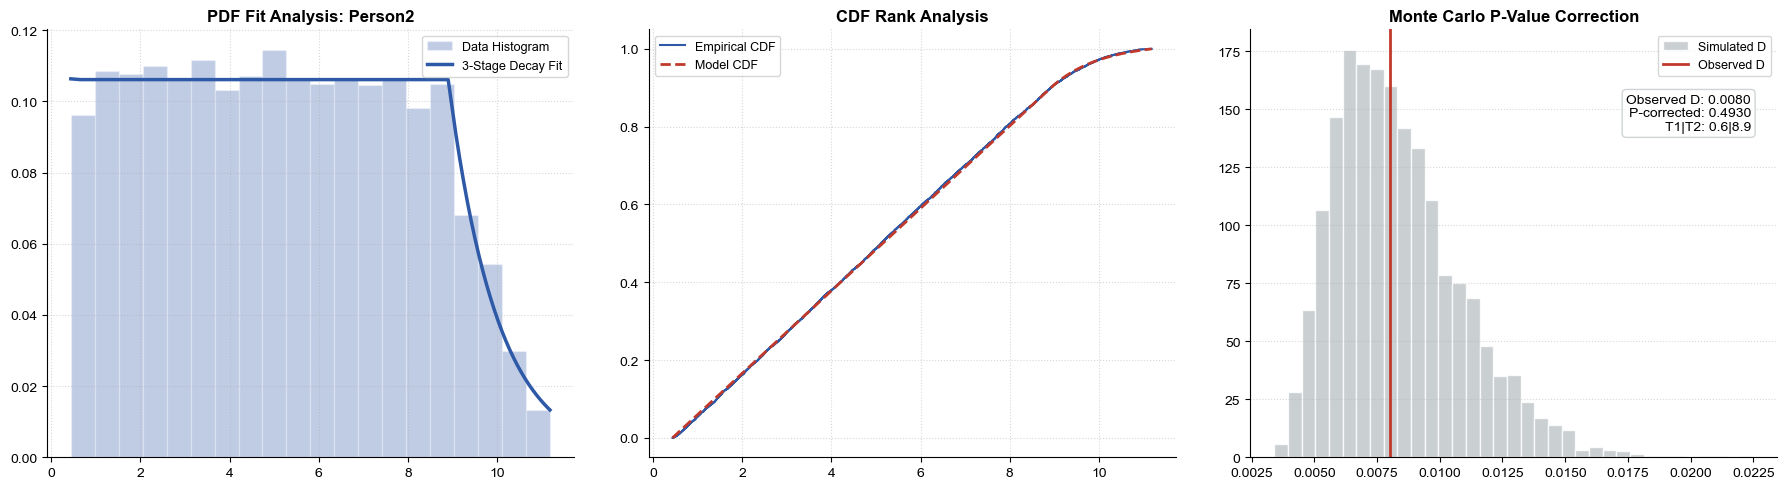

Analysis for Person2 completed. P-corrected: 0.4930


In [12]:
analyze_person_distribution(2)

Running Analysis for Person3...


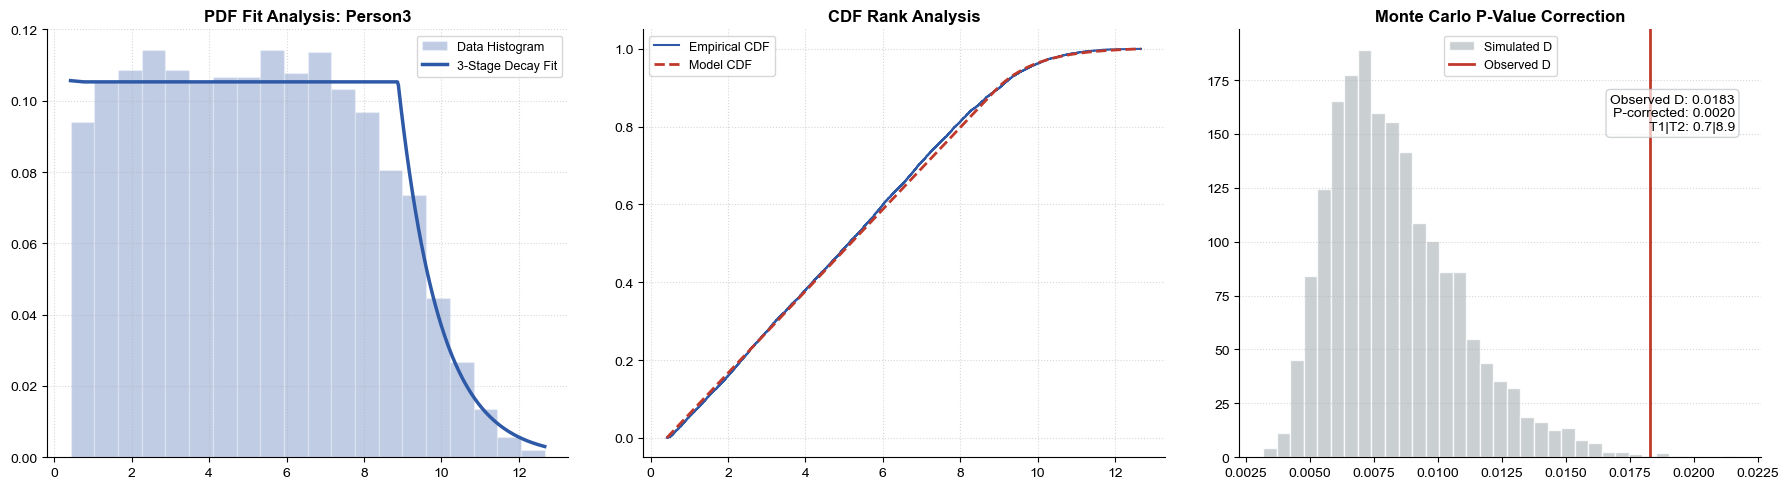

Analysis for Person3 completed. P-corrected: 0.0020


In [13]:
analyze_person_distribution(3)

Running Analysis for Person4...


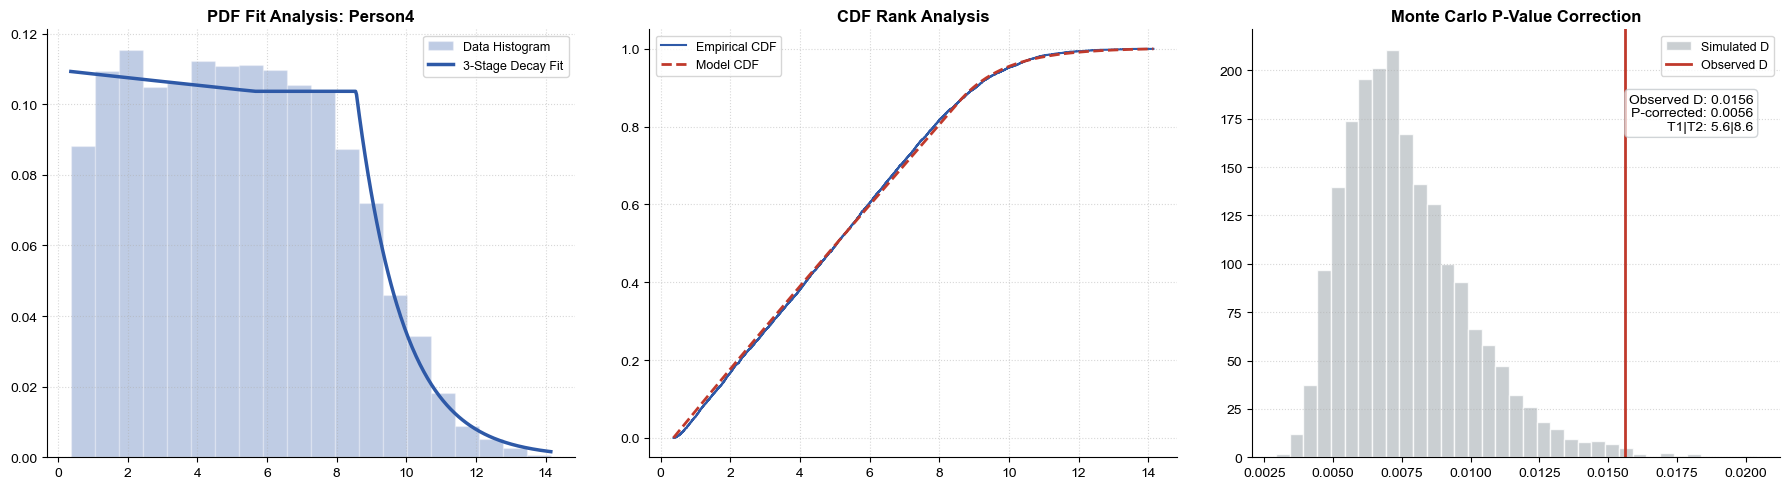

Analysis for Person4 completed. P-corrected: 0.0056


In [14]:
analyze_person_distribution(4)

Running Analysis for Person5...


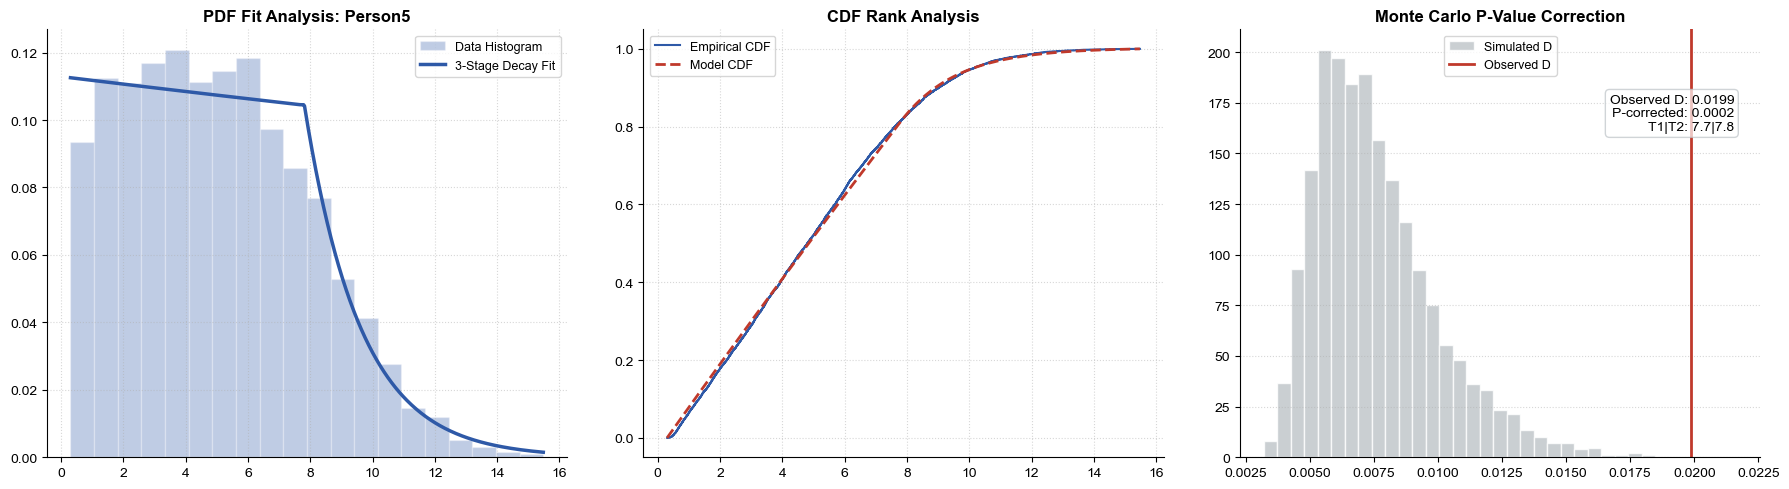

Analysis for Person5 completed. P-corrected: 0.0002


In [15]:
analyze_person_distribution(5)

Running Analysis for Person6...


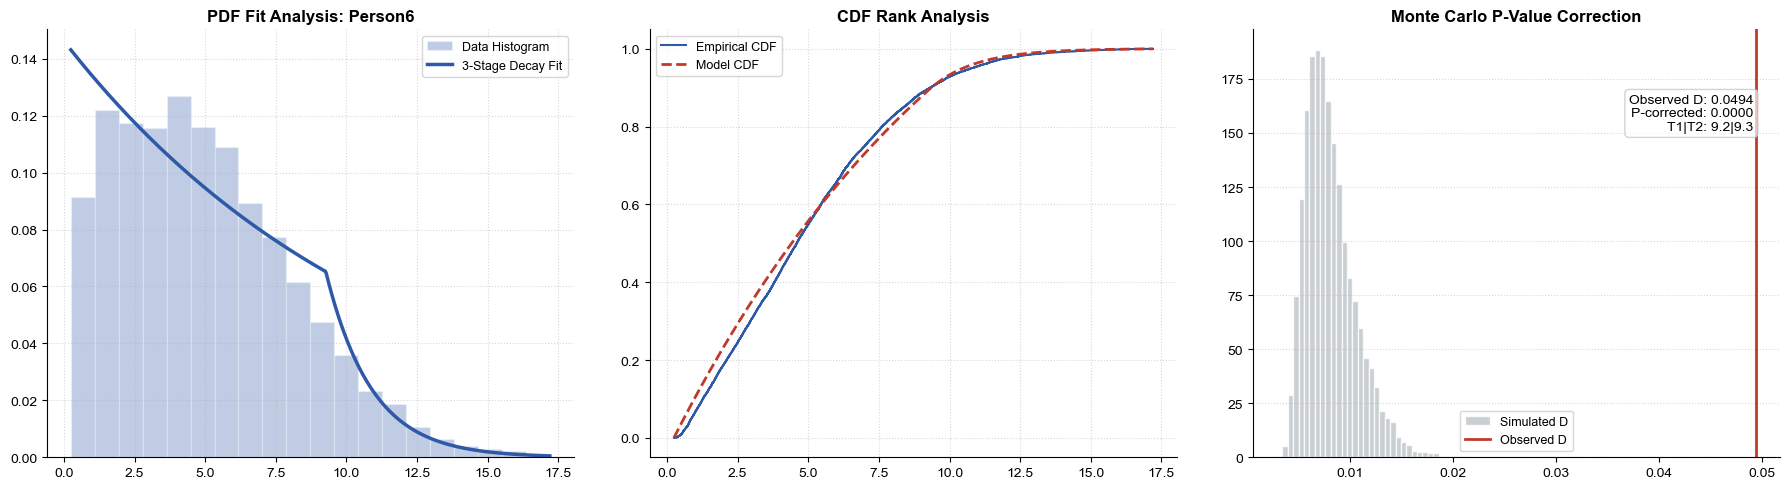

Analysis for Person6 completed. P-corrected: 0.0000


In [16]:
analyze_person_distribution(6)

Running Analysis for Person7...


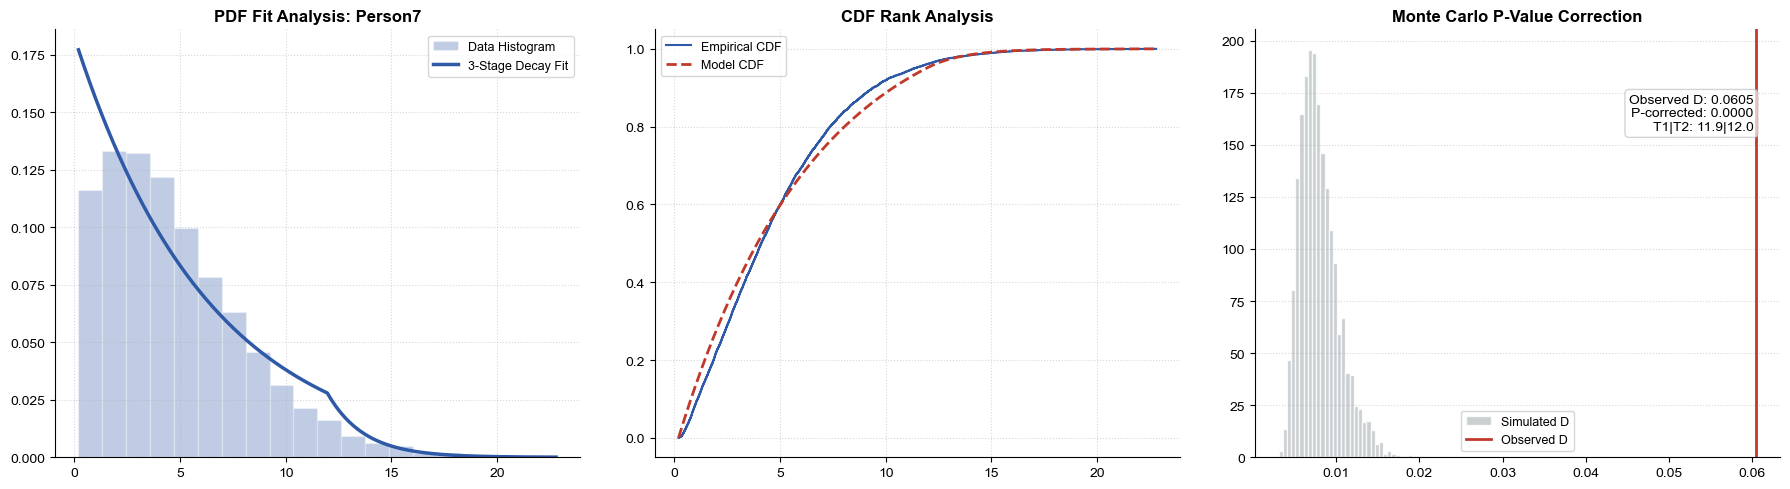

Analysis for Person7 completed. P-corrected: 0.0000


In [17]:
analyze_person_distribution(7)

Running Analysis for Person8...


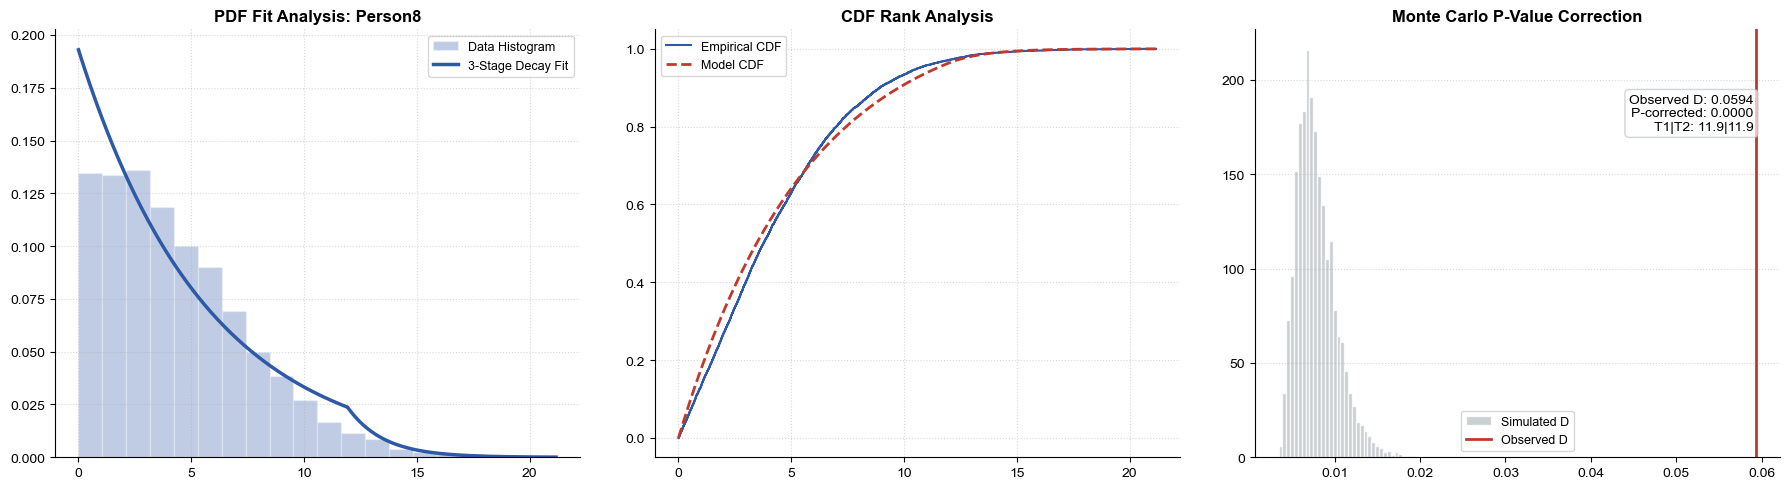

Analysis for Person8 completed. P-corrected: 0.0000


In [18]:
analyze_person_distribution(8)

##### 2.3.4 结论
由P值可知这个三段模型对于X_i(1< i < 7)的拟合效果是非常好的。当i变大时，均匀分布的区间退化为0，整个X_i分布退化为近似于指数分布，但最后一个人的分布不能用三段式模型拟合。

然而这不能说明三段模型的错误，$X_n$的偏差是由于自由度的丧失导致的。由于总金额固定，最后一人的金额 $X_8 = S - \sum_{i=1}^{7} X_i$。这意味着 Person 8 **完全没有自主的分布规律**。他不是被某种“分配逻辑”产生的，而是被前 7 个人“挤”出来的剩余物。

#### 3.推导普遍结论

##### 3.1 二倍均值法的建立

虽然现在我们通过数据拟合得到了一个可行的概率模型，但是，由于缺乏更加普遍可用的结论，使得这个模型对于显示生活的指导作用有限。因此，我们希望通过对已有数据的进一步分析，得到更加普遍的数学结论。

在上文猜测模型的过程中我们发现，$X_1$能较好的服从均匀分布，而随着$i$增大，均匀分布的部分逐渐变小。因此我们猜测$X_i$可能服从于一种条件均匀分布。同时，进一步观察$X_1$数据，我们发现$x_1$的最大值没有超过10，即两倍的平均值。

综上所述，我们提出一种可能的微信红包的机制：“二倍均值法”，即
对于第$i$个抢红包者，我们假定在其抢红包前剩余的金额为$R_i$，剩余的人数为$k$，其获得的红包金额为$X_i$。那么，$$X_i \sim Uni(0.1\frac{R_i}{k}, 2\frac{R_i}{k})$$ 该过程是一个**马尔可夫链**。

#### 3.2 模型检验
首先将每轮抢得金额得原始数据归一化为其占剩余总金额得比例。

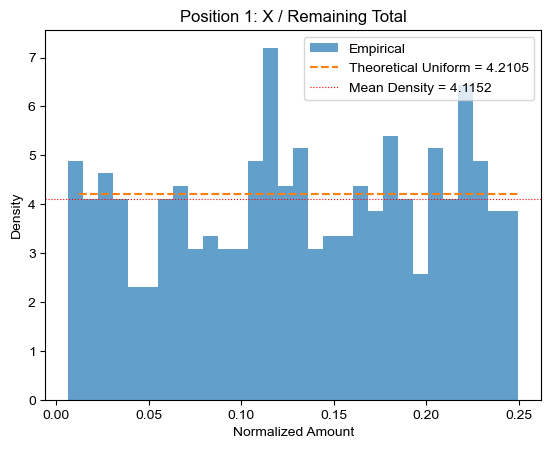

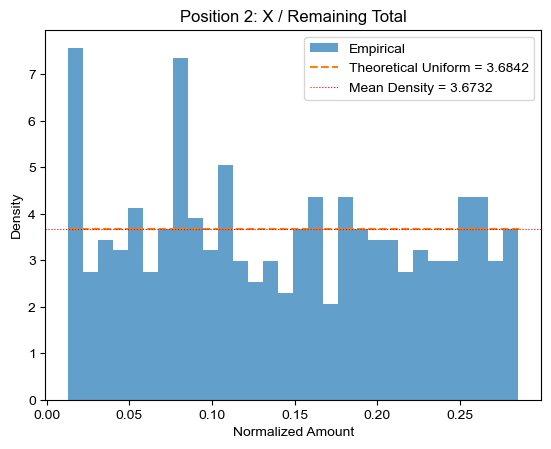

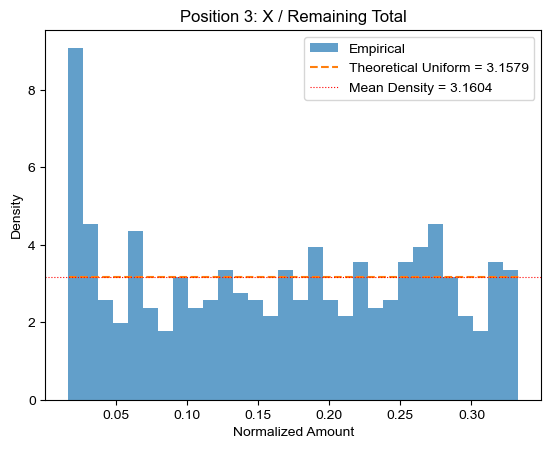

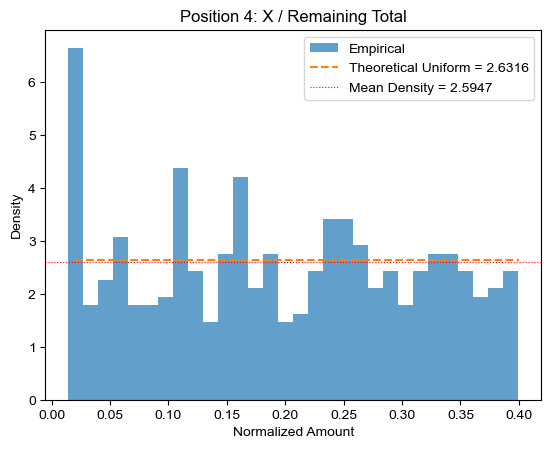

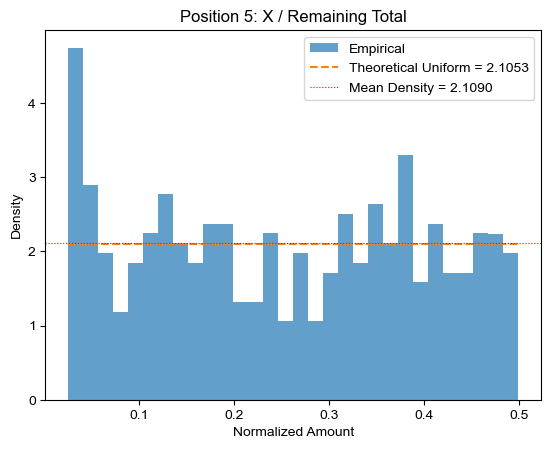

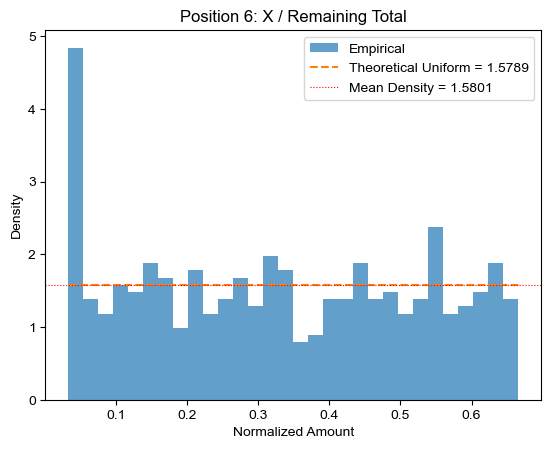

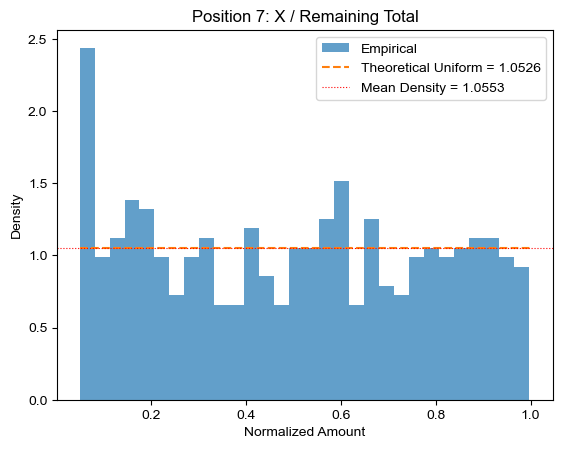

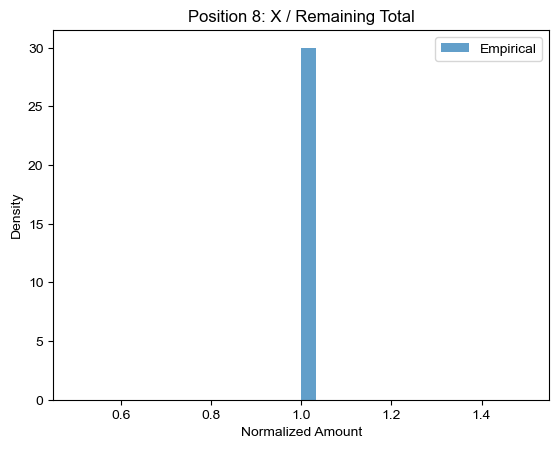

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================
# 1. 读取数据
# =====================
# 假设:
# 行 = 实验次数
# 列 = 位次 (第1个抢到的人, 第2个, ...)
df = pd.read_csv("data/real_480.csv")

# Skip the 'Trial' column (first column)
df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]

# =====================
# 2. 计算归一化比例
# =====================
ratios = {}

for i, col in enumerate(df_data.columns):
    # 剩余总额（包含自己）
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)

# =====================
# 3. 绘制直方图验证均匀分布
# =====================
for i, col in enumerate(ratio_df.columns):
    data = ratio_df[col].dropna()
    bins = 30

    # 先用 numpy 计算密度（便于求均值）
    counts, edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    # 绘制直方图（density=True）
    plt.figure()
    plt.hist(data, bins=bins, density=True, alpha=0.7, label="Empirical")

    if i < num_positions - 1:
        # 理论均匀分布区间（从0到上界）
        upper = 2 / (num_positions - i)
        lower = 0.1 / (num_positions - i)

        # 理论常数密度 = 总概率(1) / 区间长度
        theoretical_density = 1.0 / (upper - lower)

        # 经验密度的均值（所有bin的密度平均）
        mean_density = counts.mean()

        # 绘制理论密度和经验均值密度
        x = np.linspace(lower, upper, 200)
        y = np.ones_like(x) / (upper - lower)

        plt.plot(x, y, linestyle="--", label=f"Theoretical Uniform = {y[0]:.4f}")
        plt.axhline(mean_density, color='red', linestyle=':', linewidth=0.8,
                    label=f'Mean Density = {mean_density:.4f}')

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

然后进行KS检验

In [20]:
from scipy.stats import kstest

print("Kolmogorov–Smirnov Test Results")
print("-" * 50)

for i, col in enumerate(ratio_df.columns):
    # 理论均匀分布的上界
    upper = 2 / (num_positions - i)

    # 经验样本
    data = ratio_df[col].dropna().values

    # KS 检验
    # H0: data ~ Uniform(0, upper)
    ks_stat, p_value = kstest(
        data,
        'uniform',
        args=(0, upper)
    )

    print(
        f"Position {i+1:2d} | "
        f"KS statistic = {ks_stat:.4f} | "
        f"p-value = {p_value:.4f}"
    )

    # Pass/fail message in English
    if p_value > 0.05:
        print("Passes KS test")
    else:
        print("Fails KS test")
    
    print()

Kolmogorov–Smirnov Test Results
--------------------------------------------------
Position  1 | KS statistic = 0.0506 | p-value = 0.0000
Fails KS test

Position  2 | KS statistic = 0.0499 | p-value = 0.0000
Fails KS test

Position  3 | KS statistic = 0.0514 | p-value = 0.0000
Fails KS test

Position  4 | KS statistic = 0.0527 | p-value = 0.0000
Fails KS test

Position  5 | KS statistic = 0.0514 | p-value = 0.0000
Fails KS test

Position  6 | KS statistic = 0.0513 | p-value = 0.0000
Fails KS test

Position  7 | KS statistic = 0.0501 | p-value = 0.0000
Fails KS test

Position  8 | KS statistic = 0.5000 | p-value = 0.0000
Fails KS test



**Position2-7**能够通过K-S检验。**Position 1**无法通过得原因可能是左侧“保底机制”导致得异常值影响过大导致总体偏离均匀。**Position 8**（末位）的金额完全取决于前面红包的剩余，不具有独立性，证明该猜想基本正确。

#### 3.3 求解第 2 个红包金额 ($X_2$) 的概率密度函数（显式解）
不妨设：
* 总金额：$m$
* 总人数：$n$
* 第一个红包金额：
  $$
  X_1 \sim \mathrm{Uni}\left(0,\frac{2m}{n}\right)
  $$
* 第二个人抢红包前的剩余金额：
  $$
  R_2 = m - X_1
  $$
* 已知条件分布规则：
  $$
  X_2 \mid R_2
  \sim
  \mathrm{Uni}\left(
    \frac{0.1R_2}{n-1},
  \frac{2R_2}{n-1}
  \right)
  $$
* 不过在$n \ge 1$时，保底机制对于分布整体的影响可以忽略不计，为方便计算，我们将条件分布规则简化为：
  $$
  X_2 \mid R_2
  \sim
  \mathrm{Uni}\left(
    0,
  \frac{2R_2}{n-1}
  \right)
  $$

---

给定 ($R_2 = r$)，由于
$$
X_1 \sim \mathrm{Uni}\left(0,\frac{2m}{n}\right)
$$

作变量变换 ($R_2 = m - X_1$)，得到：

$$
R_2 \sim \mathrm{Uniform}!\left(
m - \frac{2m}{n}, m
\right)
$$

即：

$$
f_{R_2}(r)=

\frac{n}{2m}
\mathbf{1}_{\left[m-\frac{2m}{n},m\right]}(r)
$$


根据全概率公式：

$$
f_{X_2}(x)=\int f_{X_2 \mid R_2}(x \mid r) f_{R_2}(r),dr
$$

代入得到：

$$
f_{X_2}(x)=\int
\frac{n-1}{2r}
\cdot
\frac{n}{2m}
;
\mathbf{1}_{\left[
\max\left(m-\frac{2m}{n},\frac{(n-1)x}{2}\right),m
\right]}(r)
;dr
$$


由于积分下限是两者中的最大值：

$$
r_{\min}(x)=\max\left(
m-\frac{2m}{n},
\frac{(n-1)x}{2}
\right)
$$

这导致 **PDF 是分段函数**。

定义临界点：

$$
x_0=\frac{2}{n-1}
\left(m-\frac{2m}{n}\right)=\frac{2m(n-2)}{n(n-1)}
$$

当 $0 \le x \le \dfrac{2m(n-2)}{n(n-1)}$

此时：
$$
r_{\min} = m-\frac{2m}{n}
$$

$$
\boxed{
f_{X_2}(x)=\frac{n(n-1)}{4m}
\ln\left(\frac{n}{n-2}\right)
}
$$


当 $\dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1}$

此时：
$$
r_{\min} = \frac{(n-1)x}{2}
$$

$$
\boxed{
f_{X_2}(x)=\frac{n(n-1)}{4m}
\ln\left(
\frac{2m}{(n-1)x}
\right)
}
$$

其余情况,

$$
f_{X_2}(x) = 0
$$

---

综上，

$$
\boxed{
f_{X_2}(x)=
\begin{cases}
\dfrac{n(n-1)}{4m}
\ln\left(\dfrac{n}{n-2}\right),
& 0 \le x \le \dfrac{2m(n-2)}{n(n-1)} \\
\dfrac{n(n-1)}{4m}
\ln\left(
\dfrac{2m}{(n-1)x}
\right),
& \dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1} \\
0,
& \text{otherwise}.
\end{cases}
}
$$

如下图所示：

Total amount m = 40.0
Participant Number n= 8
Max empirical X2 = 10.86
Theoretical upper bound = 11.428571428571429
m,n= 40.0 8
A= 0.10068872535812329
x_flat= 8.571428571428571
C= 0.35


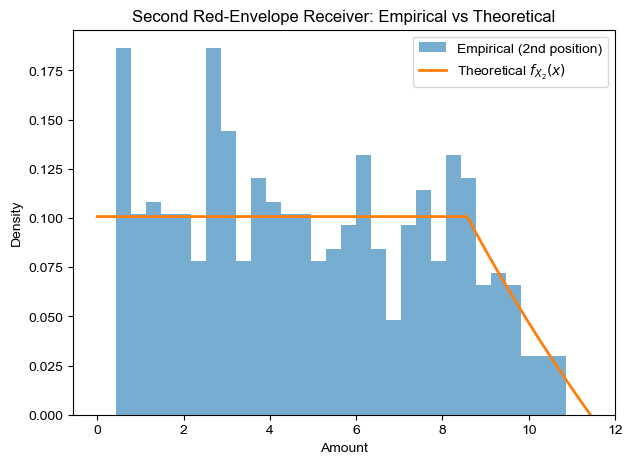

In [122]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 基本参数
# =====================
# 第二个抢红包的数据
x2_data = df.iloc[:-1, 2].values

n = df.shape[1]-1                      # 人数
m = df.sum(axis=1, numeric_only=True).iloc[1] - 2  # 总金额（从第一行取得）
print("Total amount m =", m)
print("Participant Number n=", n)
print("Max empirical X2 =", x2_data.max())
print("Theoretical upper bound =", 2 * m / (n - 1))


# =====================
# 理论 PDF 定义
# =====================
def f_X2(x, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    a = 2 * m * (n - 2) / (n * (n - 1))
    b = 2 * m / (n - 1)
    c = n * (n - 1) / (4 * m)

    mask1 = (x >= 0) & (x <= a)
    pdf[mask1] = c * np.log(n / (n - 2))

    mask2 = (x > a) & (x <= b)
    pdf[mask2] = c * np.log((2 * m) / ((n - 1) * x[mask2]) )

    print("m,n=",m,n)
    print("A=",c * np.log(n / (n - 2)))
    print("x_flat=",a)
    print("C=",c)

    return pdf

# =====================
# 作图：经验直方图 + 理论曲线
# =====================
x_grid = np.linspace(0, 2 * m / (n - 1), 500)
pdf_vals = f_X2(x_grid, n, m)

plt.figure(figsize=(7,5))
plt.hist(
    x2_data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Empirical (2nd position)"
)

plt.plot(
    x_grid,
    pdf_vals,
    linewidth=2,
    label=r"Theoretical $f_{X_2}(x)$"
)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Second Red-Envelope Receiver: Empirical vs Theoretical")
plt.legend()
plt.show()

随着$i$的增加，解析式会包含更高阶的多重对数或多项式，形式极其复杂。但我们可以定性描述其分布特征：
- 期望值不变，不难证明，对于任意 $1\le i \le n$，都有$$E[X_i]=\frac{m}{n}$$

- 极差增大：$i=1$时是均匀分布，极差最小，只能取到平均值的0.1到2倍。

$i$越大，剩余金额$S_i$的不确定性越大。后面的人有可能面临“前面的人抢很少，剩下一大笔钱”（从而抢到远超2倍均值的金额），也有可能面临“前面的人抢完了，只剩渣”（抢到几分钱）。

分布图会变得**低而宽**，即取值范围变大，但概率密度峰值降低。我们尝试求解$X_k$的近似

#### 3.4 求解$X_k$的近似PDF

观察到$X_1$和$X_2$在金额较小的区间上都为均匀分布，


根据**卷积的标准结论**：

> 两个在 $[0,a]$、$[0,b]$ 上密度常数的随机变量，其和在 $[0,\min(a,b)]$ 上仍然密度常数。

因此：

$
S_2 := X_1 + X_2
$

在一个初始区间内，其密度为：

$
f_{S_2}(s) = \text{常数}, \quad s \in [0, s_0]
$


因此，在前半区间第3个红包的金额：
$$
f_{X_3}(x)=\mathbb E\left[\frac{n-2}{2(m-X_1-X_2)}\right]
$$

对 $X_1,X_2$ 取期望：

$$
f_{X_3}(x)=A=\frac{n-2}{2}
\mathbb E\left[\frac{1}{m-X_1-X_2}\right]
$$

$$
\mathbb E\left[\frac{1}{m-X_1-X_2}\right]=\int_0^{2m/n}\int_0^{2(m-x_1)/(n-1)}
\frac{n(n-1)}{4m(m-x_1)}
\cdot
\frac{1}{m-x_1-x_2}
,dx_2,dx_1
$$

先对 $x_2$ 积分：

$$
\int_0^{2(m-x_1)/(n-1)}\frac{dx_2}{m-x_1-x_2}=\ln\frac{m-x_1}{m-x_1-\frac{2(m-x_1)}{n-1}}

\ln\frac{n-1}{n-3}
$$

这是一个**常数**。

于是：

$$
\boxed{
f_{X_3}(x)=A
=

\frac{n(n-2)}{4m}
\ln\frac{n-1}{n-3}
}
$$

##### 尾部衰减区间的主导机制


当 (x) 较大时，必须满足：

$
R_3 \ge \frac{(n-2)x}{2}
\quad\Rightarrow\quad
X_1 + X_2 \le m - \frac{(n-2)x}{2}
$


在尾部区间：

* $X_1$ 和 $X_2$ 的上界成为主要限制
* 可近似认为：
  $$
  X_1, X_2 \stackrel{\text{i.i.d.}}{\sim}
  \mathrm{Uniform}(0,2m/n)
  $$

于是 $S_2 = X_1 + X_2$ 的密度近似为**三角分布**：

$$
f_{S_2}(s)
\propto
\left(1 - \frac{s}{4m/n}\right)
$$


其中：

* (C, c) 是由 (m,n) 决定的常数
* 对数的 **平方** 来自：

  * 一次来自 (X_2) 的混合
  * 一次来自 (X_1) 的混合


> 第三个红包金额 (X_3) 的概率密度函数由两部分构成：在一段初始区间内，由于前两次分配的卷积效应，其分布呈现均匀平台；在尾部区间，大额红包只能在前两次分配均较小的情形下出现，其概率密度表现为对数平方形式的缓慢衰减。



因此无条件密度为
$$
f_{X_3}(x)=\mathbb E!\left[
\frac{n-2}{2(m-X_1-X_2)}
\mathbf !\left(
x\le \frac{2(m-X_1-X_2)}{n-2}
\right)
\right]
$$

其中，c为尾部的最大可能值：

$$
\boxed{
c=\frac{2m}{n-2}
}
$$

由归一化条件：

$$
A,x_{\text{flat}}
+
C\int_{x_{\text{flat}}}^{c}
\left[\ln\left(\frac{c}{x}\right)\right]^2dx=1$$

计算积分：

令 ($u=\ln(c/x)$)，则

$$
\int u^2 e^{-u}du=e^{-u}(u^2+2u+2)
$$

于是：

$$
\int_{x_{\text{flat}}}^{c}
\left[\ln\left(\frac{c}{x}\right)\right]^2dx=c
\Bigl[
2
-

\frac{x_{\text{flat}}}{c}
\Bigl(
\ln^2\frac{c}{x_{\text{flat}}}
+
2\ln\frac{c}{x_{\text{flat}}}
+
2
\Bigr)
\Bigr]
$$


$$
C
=
\frac{
1-A,x_{\text{flat}}
}{
c
\Bigl[
2
-

\frac{x_{\text{flat}}}{c}
\Bigl(
\ln^2\frac{c}{x_{\text{flat}}}
+
2\ln\frac{c}{x_{\text{flat}}}
+
2
\Bigr)
\Bigr]
}

$$


##### 推广到一般 $X_k$

**上界(最大可能值)**
$$
\boxed{
c_k=\frac{2m}{,n-k+1,}
}
$$

**平坦区右端点**

$$
\boxed{
x_{\mathrm{flat}}^{(k)}
=

\frac{2m}{,n-k+1,}
\prod_{i=0}^{k-2}
\frac{n-i-2}{n-i}
}
$$

**平坦区高度**
$$
\boxed{
A_k
=

\frac{n(n-k+1)}{4m}
\ln\frac{n-k+1}{n-k-1}
}
$$

**尾部系数（由连续性确定）**

$$
\boxed{
C_k=
\frac{
A_k
}{
\left[
\ln\left(
\dfrac{c_k}{x_{\mathrm{flat}}^{(k)}}
\right)
\right]^{k-1}
}
}
$$

**分段概率密度函数**

$$
\boxed{
f_{X_k}(x)
=

\begin{cases}
A_k,
& 0 \le x \le x_{\mathrm{flat}}^{(k)} \\
C_k
\left[
\ln\left(
\dfrac{c_k}{x}
\right)
\right]^{k-1},
& x_{\mathrm{flat}}^{(k)} < x \le c_k \\
0,
& \text{otherwise}.
\end{cases}
}
$$

数学上，尾部区间的$k-1$次对数函数的形式是由于对均匀分布变量做$k-1$重积分，每次积分会使阶数增加一阶。

在实际计算中，可以通过考虑每轮的保底机制极限最小情况修正$R_k$，即
$$
R_k = R_{k-1} - \frac{0.1R_{k-1}}{n-k}
$$
，从而修正$X_k$概率分布的上界。

---

#### 3.5 检验

将参数带入式子后，将理论值与实际值进行比较，得到以下结果：

In [131]:
from scipy.integrate import quad

def theoretical_params_Xk(k, n, m):
    # x_flat^{(k)}
    prod = 1.0
    bef_mx = 0.0
    for i in range(k - 1):
        prod *= (n - i - 2) / (n - i)
        bef_mx += (m - bef_mx) * 0.1 / (n - i)
    m_new = m - bef_mx  #保底机制修正 
    x_flat = (2 * m / (n - k + 1)) * prod

    # 平坦区高度 A_k
    A = (n * (n - k + 1) / (4 * m)) * np.log((n - k + 1) / (n - k - 1))
    
    # 理论上界
    c = 2 * m_new / (n - k + 1)

    # 初始 C_k（由连续性确定）
    C = A / (np.log(c / x_flat) ** (k - 1))

    # =====================
    # 归一化操作：确保积分为1
    # =====================
    # 定义临时PDF函数
    # def pdf_temp(x):
    #     if x <= x_flat:
    #         return A
    #     elif x <= c:
    #         return C_init * (np.log(c / x) ** (k - 1))
    #     else:
    #         return 0.0

    # 数值积分计算总面积
    # total_integral, _ = quad(pdf_temp, 0, c)
    
    # 计算缩放因子（使得积分 = 1）
    # scale_factor = 1.0 / total_integral if total_integral > 0 else 1.0
    
    # # 归一化后的参数
    # A = A * scale_factor
    # C = C_init * scale_factor

    return A, x_flat, C, c, bef_mx


In [132]:
def f_Xk(x, k, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    A, x_flat, C, c, bef_mx = theoretical_params_Xk(k, n, m)

    mask1 = (x >= 0) & (x <= x_flat)
    pdf[mask1] = A

    mask2 = (x > x_flat) & (x <= c)
    pdf[mask2] = C * (np.log(c / x[mask2]) ** (k - 1))

    return pdf

In [133]:
def validate_Xk(df, k, bins=30):
    # 第 k 个红包数据
    xk_data = df.iloc[:-1, k].values

    n = df.shape[1] - 1
    m = df.sum(axis=1, numeric_only=True).iloc[1] - 2

    A, x_flat, C, c, bef_mx = theoretical_params_Xk(k, n, m)

    print(f"=== X_{k} theoretical parameters ===")
    print("A =", A)
    print("x_flat =", x_flat)
    print("c =", c)
    print("C =", C)
    print("bef_mx =", bef_mx)
    print("Empirical max =", xk_data.max())

    x_grid = np.linspace(0, c, 600)
    pdf_vals = f_Xk(x_grid, k, n, m)

    plt.figure(figsize=(7, 5))
    plt.hist(
        xk_data,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f"Empirical (position {k})"
    )
    plt.plot(
        x_grid,
        pdf_vals,
        linewidth=2,
        label=rf"Theoretical $f_{{X_{k}}}(x)$"
    )

    plt.axvline(x_flat, linestyle="--", color="black", alpha=0.7,
                label=r"$x_{\mathrm{flat}}$")

    plt.xlabel("Amount")
    plt.ylabel("Density")
    plt.title(f"Position {k}: Empirical vs Theoretical")
    plt.legend()
    plt.show()

=== X_1 theoretical parameters ===
A = 0.11507282898071235
x_flat = 10.0
c = 10.0
C = 0.11507282898071235
bef_mx = 0.0
Empirical max = 9.98


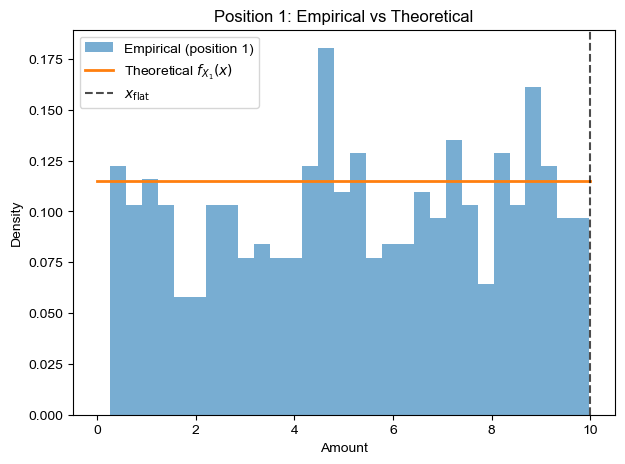

=== X_2 theoretical parameters ===
A = 0.1177652828174245
x_flat = 8.571428571428571
c = 11.285714285714286
C = 0.428076606108853
bef_mx = 0.5
Empirical max = 10.86


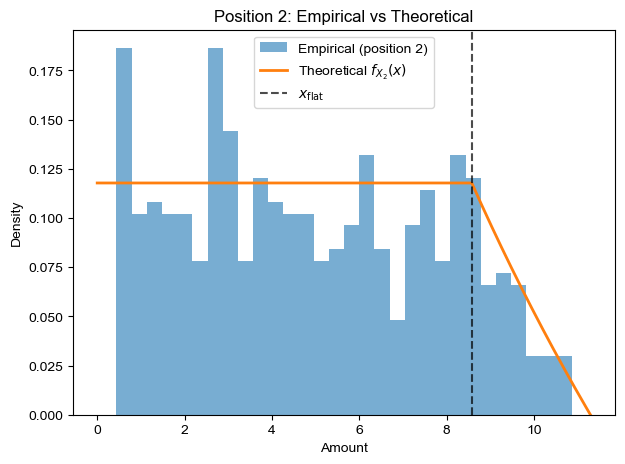

=== X_3 theoretical parameters ===
A = 0.12163953243244931
x_flat = 7.142857142857143
c = 12.978571428571428
C = 0.3410785108261623
bef_mx = 1.0642857142857143
Empirical max = 12.28


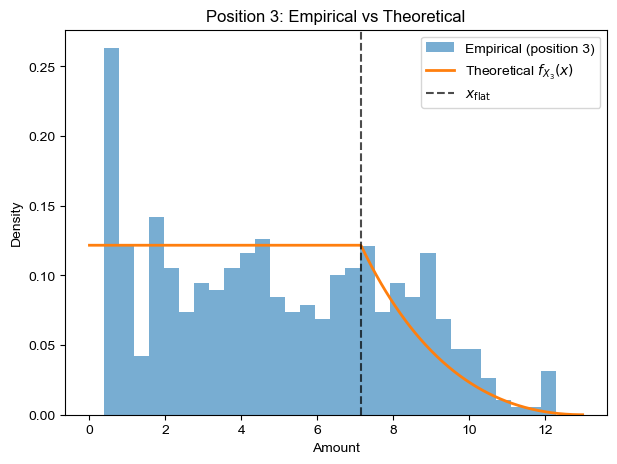

=== X_4 theoretical parameters ===
A = 0.12770640594149768
x_flat = 5.7142857142857135
c = 15.314714285714285
C = 0.13328677504642178
bef_mx = 1.7132142857142858
Empirical max = 13.19


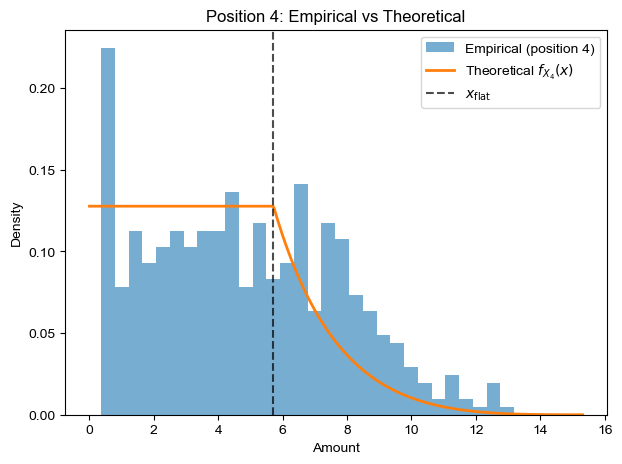

=== X_5 theoretical parameters ===
A = 0.13862943611198905
x_flat = 4.285714285714285
c = 18.760525
C = 0.029171560352112942
bef_mx = 2.47895
Empirical max = 15.82


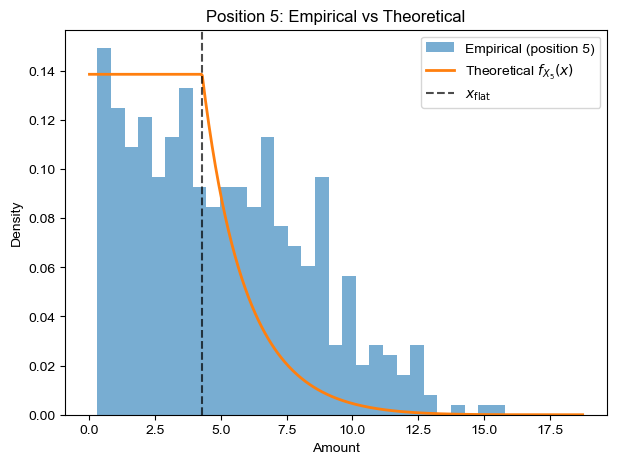

=== X_6 theoretical parameters ===
A = 0.16479184330021646
x_flat = 2.8571428571428568
c = 24.3886825
C = 0.0036350547179238506
bef_mx = 3.4169762500000003
Empirical max = 17.92


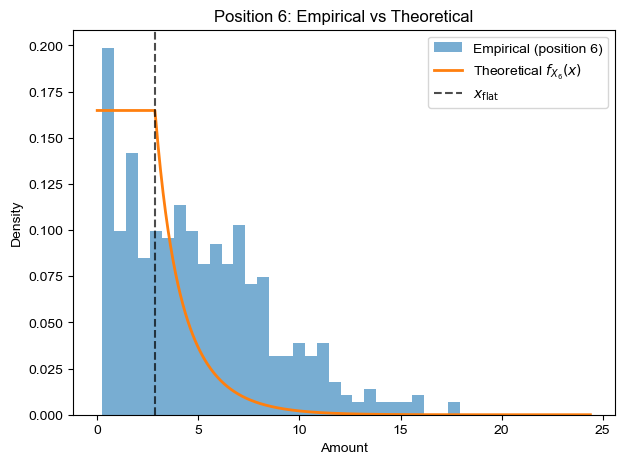

In [134]:
validate_Xk(df, k=1)
validate_Xk(df, k=2)
validate_Xk(df, k=3)
validate_Xk(df, k=4)
validate_Xk(df, k=5)
validate_Xk(df, k=6)

#### 3.6总结

在二倍均值法的模型下，我们得到的概率密度公式为：

$$
\boxed{
f_{X_k}(x)
=

\begin{cases}
A_k,
& 0 \le x \le x_{\mathrm{flat}}^{(k)} \\
C_k
\left[
\ln\left(
\dfrac{c_k}{x}
\right)
\right]^{k-1},
& x_{\mathrm{flat}}^{(k)} < x \le c_k \\
0,
& \text{otherwise}.
\end{cases}
}
$$


此公式和实际数据有较好的拟合度，同时也符合我们之前提出的三段模型，因此我们认为微信红包确实采用了二倍均值法。

事实上，这是一个“非齐次、连续状态”的马尔可夫过程，当$n$和$m$都足够大时，这个过程收敛到：

$$
\boxed{
Y \sim \mathrm{Exponential}(\lambda)
}
$$

其中
$$
\lambda=\lim_{n\to\infty}\frac{m}{n}
$$

即：

$$
X_k \xrightarrow{d} \mathrm{Exp}(\lambda)
$$

---

### 4. 扩散模型

#### 4.1 模型建立

##### 4.1.1 数据处理

In [158]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from tqdm import tqdm

# -----------------------
# Configuration
# -----------------------
CSV_PATH = "envelopes.csv"

Sum = float(input("输入每个红包的总金额"))       # total amount (given)
People = None      # inferred from data

BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-3
T = 5000           # diffusion steps

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [183]:
# -----------------------
# Load data
# -----------------------
df = pd.read_csv(CSV_PATH, header=None)
df = df.iloc[1:, 1:]
x = df.values.astype(np.float32)

People = x.shape[1]
print("人数：",People)

# Convert to proportions
p = x / Sum

# -----------------------
# MODIFIED: Centered Log-Ratio (CLR) transform
# -----------------------
# y_i = log(p_i / geometric_mean(p))
# Equivalent to: log(p_i) - mean(log(p))
eps = 1e-8
log_p = np.log(p + eps)
# Subtract the mean of logs along the last dimension (rows)
y = log_p - np.mean(log_p, axis=1, keepdims=True)

y = torch.tensor(y, dtype=torch.float32)
# Note: y shape is now (N_samples, People), not (N_samples, People-1)


人数： 8


##### 4.1.2 模型建立

- 由于红包数据有两个硬性约束：非负性（金额 > 0）和 定和性（总金额固定）。普通的神经网络很难直接输出满足 `sum(x)=M` 的结果。我们通过**CLR 变换**，模型没有直接去预测金额，而是预测了一个无约束的潜在变量 $y$，将“单纯形空间”（和为1的受限空间）映射到了“欧几里得空间”（无界实数空间）。

- 我们使用标准 Diffusion 使用高斯噪声（正态分布）产生噪声。我们考虑过引入**拉普拉斯噪声**具有更肥的尾部（Heavier tails），从而使模型在训练时就接触到了更多的极端情况，但均匀分布（Uniform）经过 Log 变换后并不像 Laplace，反而更接近某种截断的高斯或 Gumbel。标准高斯噪声对“平坦”结构的包容性比拉普拉斯强。

- 传统的 MSE (L2) Loss 对大误差非常敏感（误差平方），这会导致模型为了迎合那几个极端样本而破坏整体的规律。我们使用 对异常值更不敏感（线性惩罚）的**L1 Loss**，结合拉普拉斯噪声的数学特性（拉普拉斯分布的最大似然估计对应 L1 Loss），使得模型训练更加稳定，不会因为几个离谱的样本而导致梯度爆炸或模型崩溃。

In [184]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        t = t.float().unsqueeze(-1) / T
        return self.net(t)


In [185]:
class DenoiseMLP(nn.Module):
    def __init__(self, data_dim, hidden_dim=256):
        super().__init__()
        self.time_emb = TimeEmbedding(hidden_dim)

        self.net = nn.Sequential(
            nn.Linear(data_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_emb(t)
        x = torch.cat([x, t_emb], dim=1)
        return self.net(x)

In [ ]:
class Diffusion:
    def __init__(self, model, T):
        self.model = model
        self.T = T

        self.betas = torch.linspace(1e-4, 0.02, T).to(DEVICE)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, y0, t, noise):
        a_bar = self.alpha_bar[t].unsqueeze(1)
        return torch.sqrt(a_bar) * y0 + torch.sqrt(1 - a_bar) * noise

    def loss(self, y0):
        bsz = y0.size(0)
        t = torch.randint(0, self.T, (bsz,), device=DEVICE)
        noise = torch.randn_like(y0)

        y_t = self.q_sample(y0, t, noise)
        noise_pred = self.model(y_t, t)

       # MODIFIED: Use L1 Loss (or Huber Loss) for robustness
        return nn.L1Loss()(noise_pred, noise)

    @torch.no_grad()
    def sample(self, n_samples, data_dim):
        y = torch.randn(n_samples, data_dim).to(DEVICE)

        for t in tqdm(reversed(range(self.T)), desc="Sampling"):
            t_batch = torch.full((n_samples,), t, device=DEVICE)

            beta = self.betas[t]
            alpha = self.alphas[t]
            a_bar = self.alpha_bar[t]

            eps = self.model(y, t_batch)
            mean = (1 / torch.sqrt(alpha)) * (
                y - beta / torch.sqrt(1 - a_bar) * eps
            )

            if t > 0:
                y = mean + torch.sqrt(beta) * torch.randn_like(y)
            else:
                y = mean

        return y


##### 4.1.3 模型训练

In [207]:
dataset = torch.utils.data.TensorDataset(y)
loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True
)

# MODIFIED: data_dim is now 'People' (CLR keeps dimension), not 'People - 1'
model = DenoiseMLP(data_dim=People).to(DEVICE)

diffusion = Diffusion(model, T)
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    total_loss = 0.0
    for (y0,) in loader:
        y0 = y0.to(DEVICE)

        loss = diffusion.loss(y0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:03d} | Loss: {total_loss / len(loader):.6f}")

Epoch 001 | Loss: 0.352722
Epoch 002 | Loss: 0.113181
Epoch 003 | Loss: 0.108787
Epoch 004 | Loss: 0.100118
Epoch 005 | Loss: 0.100063
Epoch 006 | Loss: 0.098822
Epoch 007 | Loss: 0.096079
Epoch 008 | Loss: 0.098537
Epoch 009 | Loss: 0.095476
Epoch 010 | Loss: 0.102862
Epoch 011 | Loss: 0.097079
Epoch 012 | Loss: 0.093425
Epoch 013 | Loss: 0.097068
Epoch 014 | Loss: 0.089485
Epoch 015 | Loss: 0.094702
Epoch 016 | Loss: 0.099422
Epoch 017 | Loss: 0.096136
Epoch 018 | Loss: 0.097920
Epoch 019 | Loss: 0.098090
Epoch 020 | Loss: 0.098679
Epoch 021 | Loss: 0.094415
Epoch 022 | Loss: 0.097779
Epoch 023 | Loss: 0.096405
Epoch 024 | Loss: 0.097726
Epoch 025 | Loss: 0.096622
Epoch 026 | Loss: 0.093132
Epoch 027 | Loss: 0.093433
Epoch 028 | Loss: 0.096978
Epoch 029 | Loss: 0.094500
Epoch 030 | Loss: 0.090422
Epoch 031 | Loss: 0.096227
Epoch 032 | Loss: 0.096740
Epoch 033 | Loss: 0.101924
Epoch 034 | Loss: 0.099254
Epoch 035 | Loss: 0.091203
Epoch 036 | Loss: 0.094676
Epoch 037 | Loss: 0.091675
E

#### 4.2 模型检验

##### 4.2.1 生成数据


In [203]:
import pandas as pd
import numpy as np

x_gen = np.vstack([
    round_to_cents_preserve_sum(row, decimals=2)
    for row in x_gen_continuous
])

num_people = x_gen.shape[1]
column_names = [f'Person{i+1}' for i in range(num_people)]

# 2. 创建 DataFrame 并指定列名
df = pd.DataFrame(x_gen, columns=column_names)

# 3. 设置 Trial 索引 (从 1 开始，而不是默认的 0)
df.index = np.arange(1, n_samples + 1)
df.index.name = 'Trial'  # 设置索引名称为 Trial

df.to_csv(
    "generated_samples.csv",
    index=True,  
    header=True   
)

print("\nTotal sum per row:", np.unique(x_gen.sum(axis=1)))


Total sum per row: [39.999996 40.       40.000004]


##### 4.2.2 数据检验

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "generated_samples.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:].reset_index(drop=True)

# 3. 从data直接获取参数
number = data.shape[0] - 1 
people = data.shape[1] - 1  
money = data.iloc[:-1, 1:].sum(axis=1).iloc[0] 

# 4. 位次列
pos_cols = data.columns[1:people+1]

# 5. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 6. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(f"number: {number}, people: {people}, money: {money}")
print(stats)

number: 998, people: 8, money: 40.0
            mean   variance       std  median   min    max
pos_id                                                    
1       5.053944   6.840035  2.615346    5.10  0.29  13.76
2       5.070190   7.817113  2.795910    4.82  0.32  13.77
3       5.036787   9.322036  3.053201    4.55  0.25  14.32
4       4.721071   8.076676  2.841949    4.33  0.22  14.72
5       5.188879   9.792226  3.129253    4.84  0.34  17.88
6       5.228659  10.749277  3.278609    4.78  0.30  20.45
7       4.641481  11.877764  3.446413    3.64  0.17  21.32
8       5.058989  11.798041  3.434828    4.57  0.03  21.15


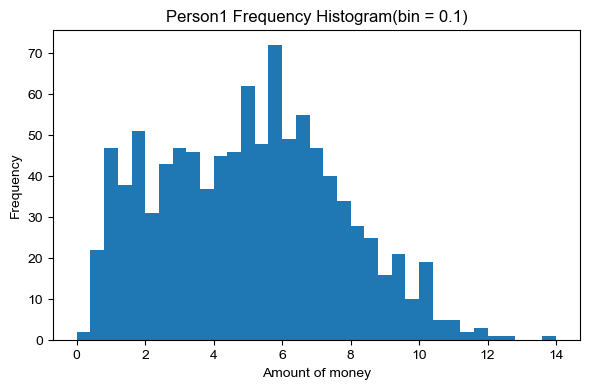

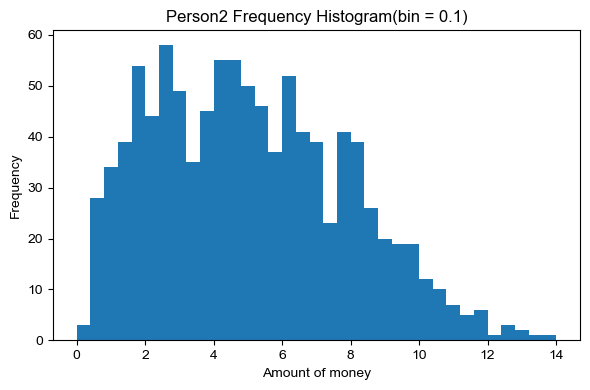

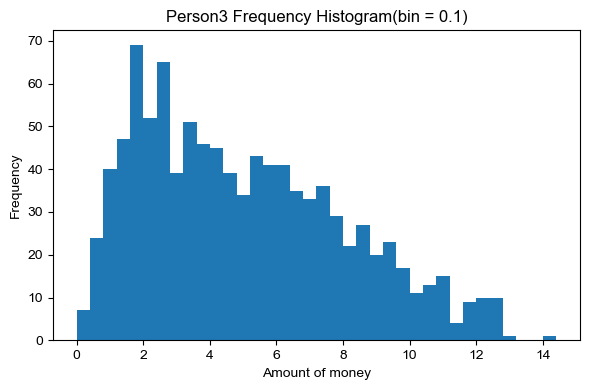

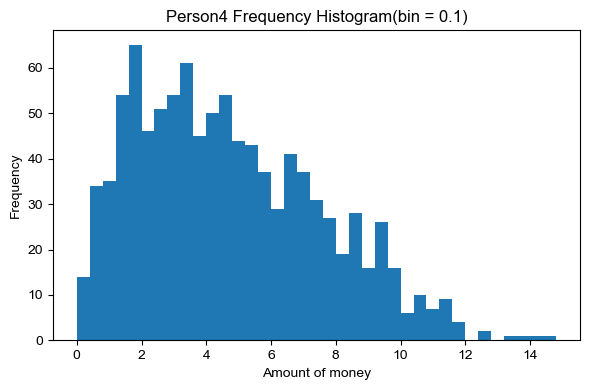

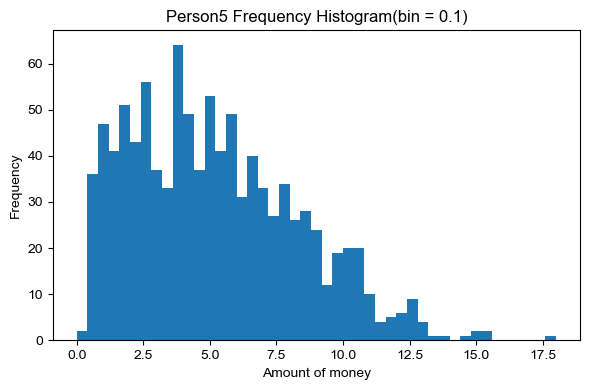

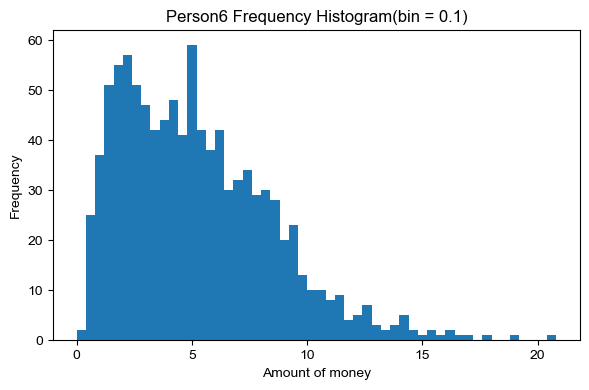

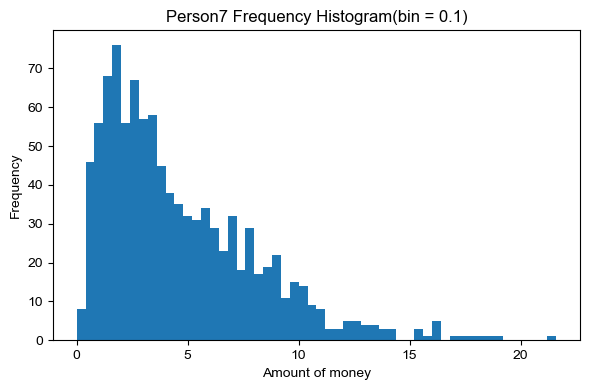

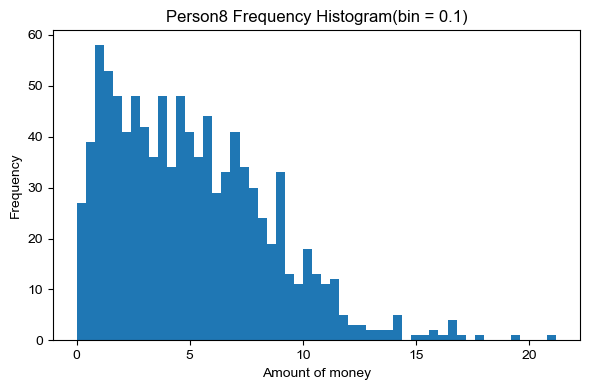

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.4      2
         1           0.4        0.8     22
         2           0.8        1.2     47
         3           1.2        1.6     38
         4           1.6        2.0     51


In [194]:
# 4. 直方图区间宽度
bin_width = 0.4

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest
import io
df = pd.read_csv('generated_samples.csv')
def analyze_person_distribution(person_num):
    """
    全过程分析函数：拟合三段式(衰减-平台-衰减)分布并进行蒙特卡洛P值修正
    参数 person_num: 整数，对应 Person1, Person2...
    """
    # --- 1. 数据提取与预处理 ---
    target_col = f'Person{person_num}'
    # 假设 df 已经在全局作用域中定义
    df_clean = df[df['Trial'] != 'Total'].copy()
    data = df_clean[target_col].astype(float).values
    n_samples = len(data)
    v_min, v_max = data.min(), data.max()

    # --- 2. 模型核心数学定义 ---
    def get_params(t1, t2, l1, l2, a, b):
        area1 = (np.exp(l1 * (t1 - a)) - 1) / max(l1, 1e-10)
        area2 = t2 - t1
        area3 = (1 - np.exp(-l2 * (b - t2))) / max(l2, 1e-10)
        k = 1.0 / (area1 + area2 + area3)
        p1 = k * area1
        p2 = p1 + k * area2
        return k, p1, p2

    def pdf_func(x, t1, t2, l1, l2, a, b):
        k, _, _ = get_params(t1, t2, l1, l2, a, b)
        pdf = np.zeros_like(x)
        m1, m2, m3 = (x < t1), (x >= t1) & (x <= t2), (x > t2)
        pdf[m1] = k * np.exp(l1 * (t1 - x[m1]))
        pdf[m2] = k
        pdf[m3] = k * np.exp(-l2 * (x[m3] - t2))
        return pdf

    def cdf_func(x, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        cdf = np.zeros_like(x)
        m1 = (x >= a) & (x < t1)
        cdf[m1] = k * (np.exp(l1 * (t1 - a)) - np.exp(l1 * (t1 - x[m1]))) / max(l1, 1e-10)
        m2 = (x >= t1) & (x <= t2)
        cdf[m2] = p1 + k * (x[m2] - t1)
        m3 = (x > t2) & (x <= b)
        cdf[m3] = p2 + k * (1 - np.exp(-l2 * (x[m3] - t2))) / max(l2, 1e-10)
        cdf[x > b] = 1.0
        return np.clip(cdf, 0, 1)

    def rvs_func(size, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        u = np.random.random(size)
        res = np.zeros(size)
        i1, i2, i3 = (u < p1), (u >= p1) & (u < p2), (u >= p2)
        res[i1] = t1 - np.log(np.exp(l1 * (t1 - a)) - u[i1] * l1 / k) / max(l1, 1e-10)
        res[i2] = t1 + (u[i2] - p1) / k
        res[i3] = t2 - np.log(1 - (u[i3] - p2) * l2 / k) / max(l2, 1e-10)
        return np.clip(res, a, b)

    # --- 3. 拟合与蒙特卡洛模拟 ---
    def nll(p, obs):
        t1, t2, l1, l2 = p
        if t1 >= t2 or t1 <= v_min or t2 >= v_max or l1 <= 0 or l2 <= 0: return 1e12
        return -np.sum(np.log(pdf_func(obs, t1, t2, l1, l2, v_min, v_max) + 1e-12))

    # 初始拟合
    bnds = [(v_min+0.2, v_max-0.2), (v_min+0.2, v_max-0.2), (0.01, 5), (0.01, 5)]
    res_obs = minimize(nll, x0=[v_min+1, v_max-1, 0.5, 0.5], args=(data,), bounds=bnds)
    t1_o, t2_o, l1_o, l2_o = res_obs.x
    
    # 观测到的 D 统计量
    d_obs = kstest(data, lambda x: cdf_func(x, t1_o, t2_o, l1_o, l2_o, v_min, v_max)).statistic

    # 蒙特卡洛 5000 次
    n_sims = 5000
    d_sims = []
    print(f"Running Analysis for {target_col}...")
    for _ in range(n_sims):
        s_data = rvs_func(n_samples, t1_o, t2_o, l1_o, l2_o, v_min, v_max)
        # 快速拟合获取模拟 D 值
        s_res = minimize(nll, x0=[t1_o, t2_o, l1_o, l2_o], args=(s_data,), bounds=bnds, tol=1e-1)
        d_sims.append(kstest(s_data, lambda x: cdf_func(x, *s_res.x, v_min, v_max)).statistic)

    p_corrected = np.mean(np.array(d_sims) >= d_obs)

    # --- 4. 绘图 (比例 18:5) ---
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    x_grid = np.linspace(v_min, v_max, 500)

    # Ax1: Histogram & PDF
    ax1.hist(data, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
    ax1.plot(x_grid, pdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), color='#2E59A7', lw=2.5, label='3-Stage Decay Fit')
    ax1.set_title(f'PDF Fit Analysis: {target_col}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, linestyle=':', alpha=0.5); ax1.spines[['top','right']].set_visible(False)

    # Ax2: CDF Comparison
    ax2.step(np.sort(data), np.arange(1, n_samples+1)/n_samples, label='Empirical CDF', color='#2E59A7', lw=1.5)
    ax2.plot(x_grid, cdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), label='Model CDF', color='#C0392B', ls='--', lw=2)
    ax2.set_title('CDF Rank Analysis', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.5); ax2.spines[['top','right']].set_visible(False)

    # Ax3: MC Rank
    ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D')
    ax3.axvline(d_obs, color='#C0392B', lw=2, label='Observed D')
    ax3.set_title('Monte Carlo P-Value Correction', fontweight='bold')
    info = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nT1|T2: {t1_o:.1f}|{t2_o:.1f}'
    ax3.text(0.95, 0.85, info, transform=ax3.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='#BDC3C7'))
    ax3.legend(fontsize=9); ax3.grid(True, linestyle=':', alpha=0.5, axis='y'); ax3.spines[['top','right']].set_visible(False)

    plt.tight_layout(w_pad=3.0)
    plt.show()
    
    print(f"Analysis for {target_col} completed. P-corrected: {p_corrected:.4f}")



选取第一个人、第五个人和第六个人的PDF进行检验。

Running Analysis for Person1...


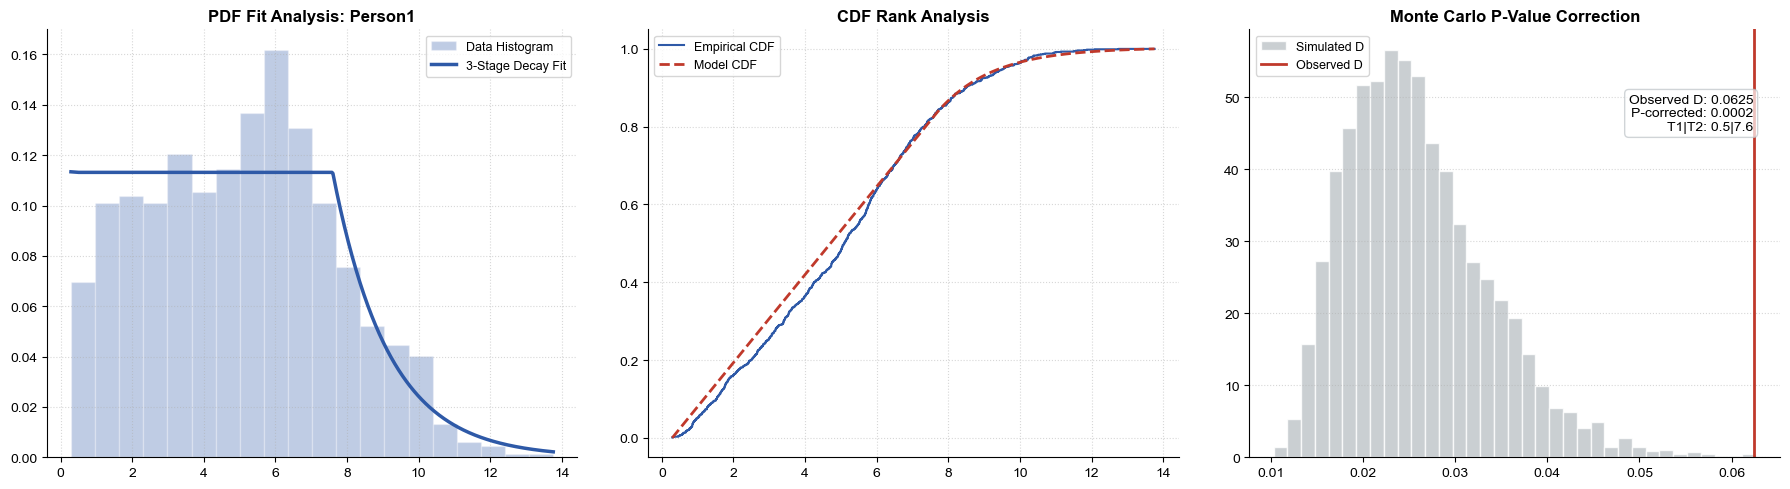

Analysis for Person1 completed. P-corrected: 0.0002


In [197]:
# 分析第一个人
analyze_person_distribution(1)

Running Analysis for Person5...


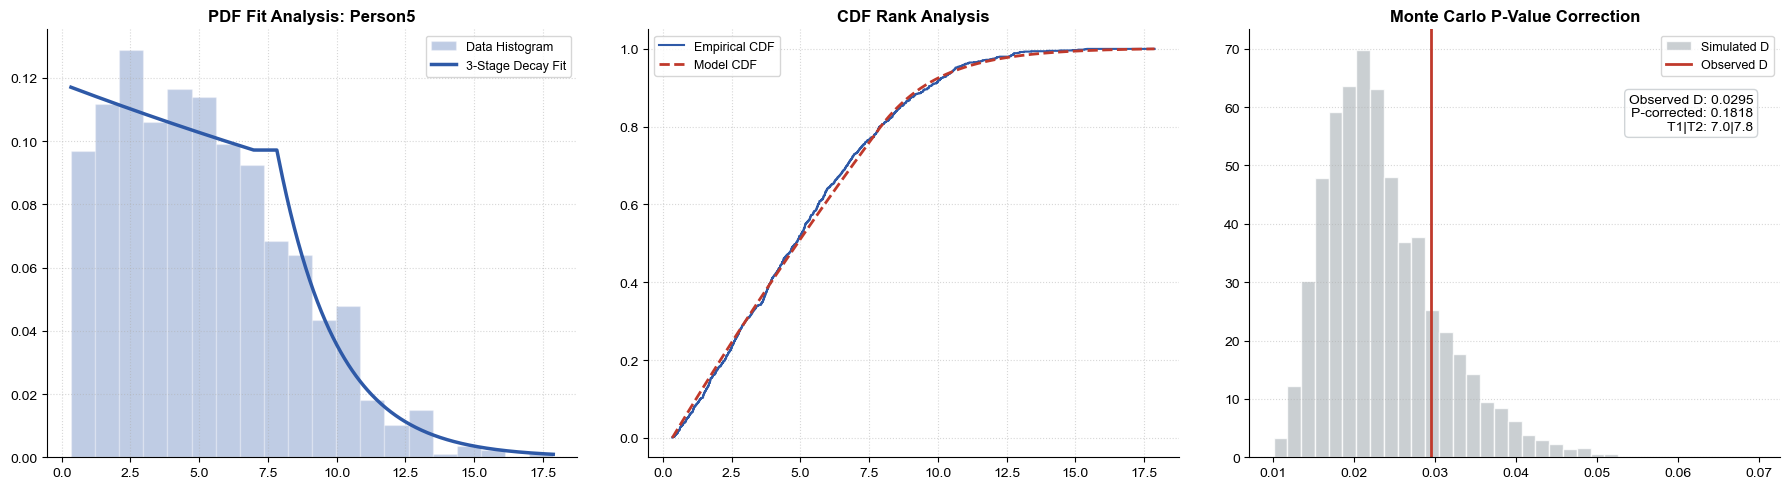

Analysis for Person5 completed. P-corrected: 0.1818


In [198]:
# 分析第五个人
analyze_person_distribution(5)

Running Analysis for Person6...


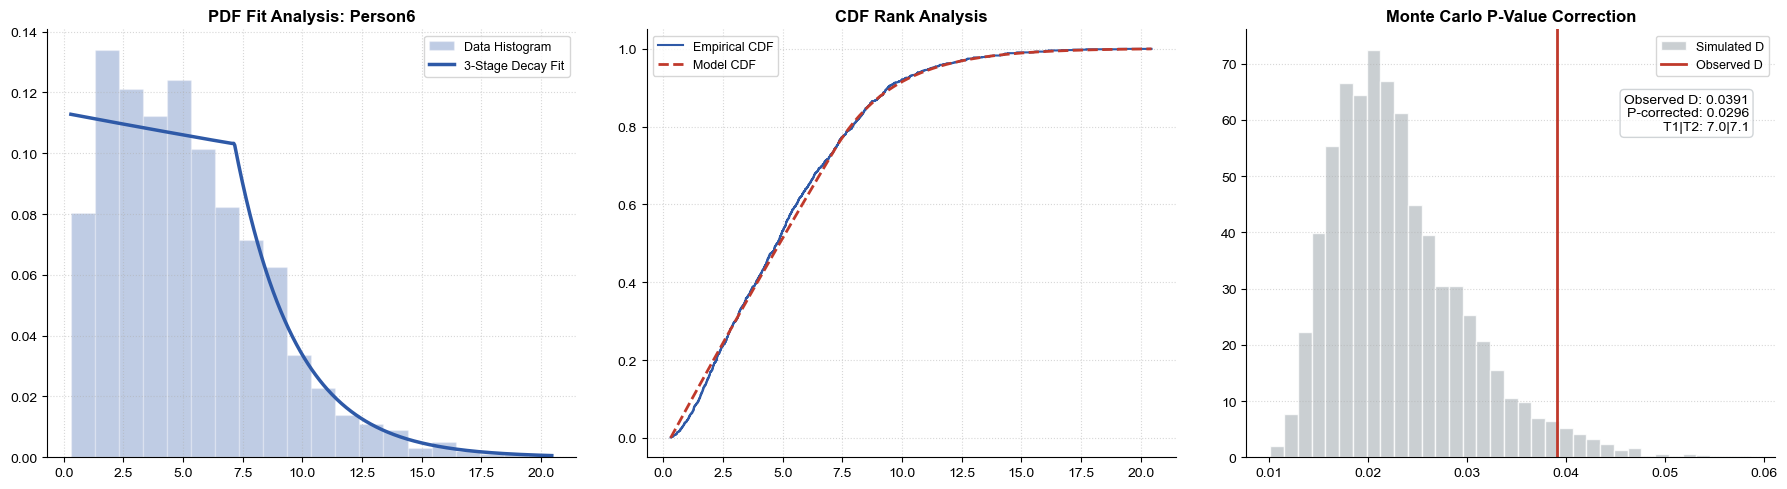

Analysis for Person6 completed. P-corrected: 0.0296


In [199]:
# 分析第六个人
analyze_person_distribution(6)

- 我们发现扩散模型扩散模型生成数据对于第一个人（均匀分布主导）的分布模型学习能力较差，但相比之前在前半段更加“均匀”。真正的均匀分布在边界处是断崖式下跌的（Hard Cutoff）。但扩散模型基于高斯核（Gaussian Kernel）进行卷积去噪，它天生倾向于生成平滑、连续的边缘。因此，它无法在均匀分布的末端实现“干净”的截断，而是表现出了一段平滑衰减的“拖尾”。

- 但当位次逐渐增加，其学习能力逐渐变好，对于k=5和k=6的数据，扩散模型生成数据已经基本符合原始数据的分布规律，且学习能力对比使用拉普拉斯噪声并没有明显降低。

综上，扩散模型可以用于生成$k>>1$时的第k位抢红包金额数据，但在k较小时与原始数据的差异较大，且很难在不引入先验知识的情况下学习到正确的分布规律。

#### 5. 抢红包策略规划

##### 5.1.研究背景&目的
现在我们已经了解的微信红包的底层运算机制，那么我们在实际生活中，我们该如何利用这个机制来是自己在抢红包的战场上所想披靡呢？在当下的微信红包群中，一般都使用手气最佳接龙的规则，即上一个红包抢到最大金额的成员发下一个红包，因此，为了使自己抢到的金额最大化，我们需要一个策略。

##### 5.2.策略设计

##### 5.2.0 假设

1. 每次抢红包的个数N固定且小于参与抢红包的总人数（即每个红包都被抢完）
2. 接龙的红包金额M固定

##### 5.2.1 “抢第二”策略

由于抢到最大金额要发下一个红包，因此，抢第二大似乎是一个很合理的策略。

然而，抢第二大红包的概略最大往往意味着同样拥有较大的概率抢到最大的红包，而发出的红包金额一定大于抢到的金额，因此“抢第二”似乎不是一个很好的策略

##### 5.2.2 “手气最佳最少”策略

在抢红包的过程中我们的期望可以表示为；
$$E[X]=E_{in}[X]-E_{out}[X]$$
其中，$E_{in}[X]$表示抢到红包金额的期望，$E_{out}[X]$表示发出红包金额的期望。

而在上面的研究中我们已经发现了不同抢红包次序的期望是相同的，因此，我们只需要找到最小的$E_{out}[X]$即可。

$E_{out}[X]$可以进一步表示为：
$$E_{out}^{[i]}[X]=P_{best}^{[i]}*M$$
其中，$P_{best}^{[i]}$表示第i个人抢岛最大金额的概率，则问题可以进一步转化为找到最小的$P_{best}^{[i]}$

##### 5.3.数据统计 & 可视化

##### 5.3.1 数据统计

由于我们已经知道了微信红包使用的是二倍均值法，因此我们可以使用代码进行大量数据的生成，减少误差


In [ ]:
# 代码块1：导入必要的库
import random
import time
import subprocess
import sys
import os

def install_packages():
    """自动安装必要的Python包"""
    packages = ['matplotlib', 'numpy', 'seaborn']
    installed_packages = []
    
    for package in packages:
        try:
            __import__(package)
            installed_packages.append(package)
        except ImportError:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
                installed_packages.append(package)
            except:
                print(f"安装 {package} 失败")
    
    return installed_packages

# 检查并安装包
installed_packages = install_packages()

In [ ]:
# 代码块2：定义红包模拟函数
def simulate_red_packet(N, trials=100000):
    """
    模拟二倍均值法红包
    N: 红包个数
    trials: 模拟次数
    返回: 每个位置成为手气最佳的概率列表
    """
    best_counts = [0] * N
    
    for _ in range(trials):
        amounts = []
        remaining = 1.0
        
        for i in range(N):
            if i == N - 1:
                amount = remaining
            else:
                max_amount = 2 * remaining / (N - i)
                amount = random.random() * max_amount
            
            amounts.append(amount)
            remaining -= amount
        
        max_amount = max(amounts)
        best_index = amounts.index(max_amount)
        best_counts[best_index] += 1
    
    probabilities = [count / trials for count in best_counts]
    return probabilities

In [ ]:
# 代码块3：运行模拟并获取数据 (N=2到20)
N_values = list(range(2, 21))
probabilities_data = {}

print("正在模拟红包数据...")
for N in N_values:
    probabilities = simulate_red_packet(N, 1000000)
    probabilities_data[N] = probabilities
    print(f"已模拟 N={N}，最佳位置: {probabilities.index(max(probabilities)) + 1}")

正在模拟红包数据...
已模拟 N=2，最佳位置: 1
已模拟 N=3，最佳位置: 1
已模拟 N=4，最佳位置: 1
已模拟 N=5，最佳位置: 1
已模拟 N=6，最佳位置: 1
已模拟 N=7，最佳位置: 1
已模拟 N=8，最佳位置: 7
已模拟 N=9，最佳位置: 9
已模拟 N=10，最佳位置: 9
已模拟 N=11，最佳位置: 10
已模拟 N=12，最佳位置: 12
已模拟 N=13，最佳位置: 12
已模拟 N=14，最佳位置: 14
已模拟 N=15，最佳位置: 14
已模拟 N=16，最佳位置: 16
已模拟 N=17，最佳位置: 16
已模拟 N=18，最佳位置: 18
已模拟 N=19，最佳位置: 19
已模拟 N=20，最佳位置: 19


##### 5.3.2 数据可视化

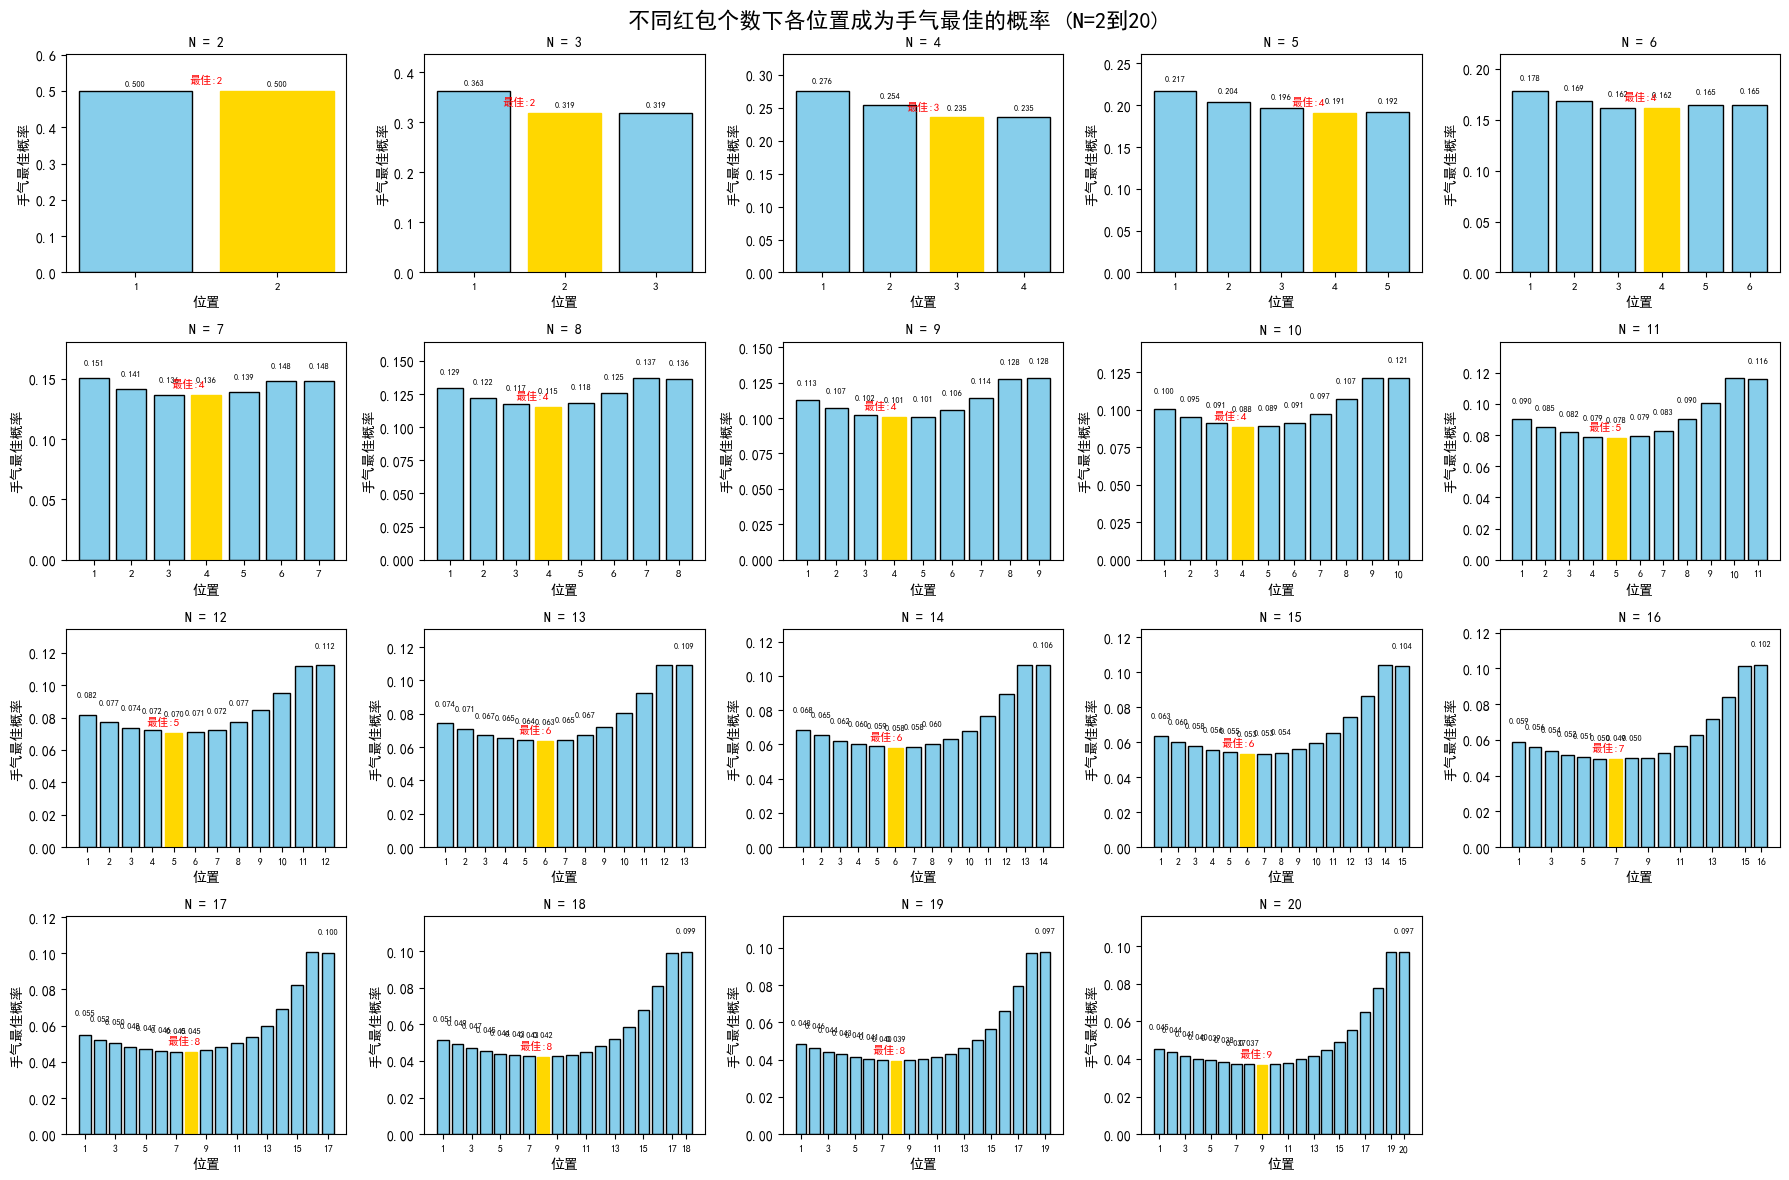


最佳位置汇总:
----------------------------------------
  N     最佳位置       最佳概率     最差位置       最差概率
----------------------------------------
  2        1     0.5004        2     0.4996
  3        1     0.3627        2     0.3185
  4        1     0.2757        3     0.2351
  5        1     0.2173        4     0.1911
  6        1     0.1784        4     0.1616
  7        1     0.1507        4     0.1363
  8        7     0.1370        4     0.1153
  9        9     0.1283        4     0.1006
 10        9     0.1210        4     0.0884
 11       10     0.1166        5     0.0780
 12       12     0.1123        5     0.0702
 13       12     0.1092        6     0.0634
 14       14     0.1062        6     0.0578
 15       14     0.1040        6     0.0531
 16       16     0.1018        7     0.0492
 17       16     0.1004        8     0.0454
 18       18     0.0992        8     0.0424
 19       19     0.0974        8     0.0393
 20       19     0.0965        9     0.0366
-----------------------------

In [ ]:
# 代码块4：生成柱状图 (N=2到20)
if 'matplotlib' in installed_packages and 'numpy' in installed_packages:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 设置中文字体
    try:
        plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
    except:
        pass
    
    # 创建输出目录
    os.makedirs('visualizations', exist_ok=True)
    
    # 计算子图的行数和列数
    num_plots = len(N_values)
    num_cols = 5  # 每行5个子图
    num_rows = (num_plots + num_cols - 1) // num_cols  # 向上取整
    
    # 柱状图 (N=2到20)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 12))
    axes = axes.flatten()  # 将二维数组展平为一维
    
    for idx, (N, probs) in enumerate(probabilities_data.items()):
        ax = axes[idx]
        positions = list(range(1, N + 1))
        
        bars = ax.bar(positions, probs, color='skyblue', edgecolor='black')
        ax.set_title(f'N = {N}', fontsize=10, fontweight='bold')
        ax.set_xlabel('位置')
        ax.set_ylabel('手气最佳概率')
        ax.set_xticks(positions)
        
        # 设置x轴刻度标签，每隔几个显示一个
        if N <= 8:
            ax.set_xticks(positions)
            ax.set_xticklabels(positions, fontsize=8)
        else:
            # 对于较大的N，只显示部分刻度
            step = max(1, N // 8)
            visible_ticks = positions[::step]
            if positions[-1] not in visible_ticks:
                visible_ticks = visible_ticks + [positions[-1]]
            ax.set_xticks(visible_ticks)
            ax.set_xticklabels(visible_ticks, fontsize=7)
        
        ax.set_ylim(0, max(probs) * 1.2)
        
        # 在柱子上添加数值 (只在前几个位置显示，避免过于拥挤)
        max_visible_bars = 8  # 最多显示8个柱子的数值
        for bar_idx, (bar, prob) in enumerate(zip(bars, probs)):
            if bar_idx < max_visible_bars or bar_idx == len(bars) - 1:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{prob:.3f}', ha='center', va='bottom', fontsize=6)
        
        # 标记最佳位置
        net_gains = [1.0/N - prob for prob in probs]
        best_index = net_gains.index(max(net_gains))
        bars[best_index].set_color('gold')
        
        # 添加最佳位置标签
        ax.annotate(f'最佳:{best_index+1}', 
                   xy=(best_index+0.5, probs[best_index]), 
                   xytext=(0, 5), 
                   textcoords='offset points', 
                   ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='red')
    
    # 隐藏多余的子图
    for idx in range(len(probabilities_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('不同红包个数下各位置成为手气最佳的概率 (N=2到20)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('visualizations/概率分布柱状图_N2-20.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 生成汇总数据表
    print("\n最佳位置汇总:")
    print("-" * 40)
    print(f"{'N':>3} {'最佳位置':>8} {'最佳概率':>10} {'最差位置':>8} {'最差概率':>10}")
    print("-" * 40)
    
    for N in N_values:
        probs = probabilities_data[N]
        best_idx = probs.index(max(probs))
        worst_idx = probs.index(min(probs))
        print(f"{N:3d} {best_idx+1:8d} {probs[best_idx]:10.4f} {worst_idx+1:8d} {probs[worst_idx]:10.4f}")
    
    print("-" * 40)
    
    # 计算并显示趋势
    best_positions = []
    for N in N_values:
        probs = probabilities_data[N]
        net_gains = [1.0/N - prob for prob in probs]
        best_index = net_gains.index(max(net_gains))
        best_positions.append(best_index + 1)
    
    print(f"\n最佳位置趋势:")
    print(f"平均最佳位置: {np.mean(best_positions):.2f}")
    print(f"中位数最佳位置: {np.median(best_positions):.1f}")
    print(f"最常出现的最佳位置: {max(set(best_positions), key=best_positions.count)}")
    
else:
    print("缺少必要的可视化库，无法生成图片")

##### 5.3.3 数据分析

从柱状图中不难得到以下结论：
1. 当N较小时（N<5），抢到手气最佳的概率随抢红包的先后顺序逐渐下降
2. 当N较大时（N>8），抢到手气最佳的概率呈现单峰性，在$\frac{N}{2}$取到最小值，在$N$取到最大值


##### 5.4.数学推演

##### 5.4.1 基本参数

##### 固定参数:
- 总人数：$N$
- 总金额：$S_0 = 1$（不失一般性，线性缩放）

##### 定义随机变量：
- 第 $i$ 个红包金额：$X_i$
- 第 $i$ 步剩余金额：$S_i = 1 - \sum_{j=1}^{i} X_j$

##### 5.4.2 条件分布
当剩余人数为 $k = N - i + 1$，剩余金额为 $S_{i-1}$ 时：

$$X_i | S_{i-1} \sim \text{Uniform}\left(0, \frac{2S_{i-1}}{k}\right)$$

并且： $$S_i = S_{i-1} - X_i$$

这是一个非齐次马尔可夫过程。

##### 5.4.3 归一化形式

定义比例变量： $$Y_i = \frac{X_i}{S_{i-1}}$$

则： $$Y_i \sim \text{Uniform}\left(0, \frac{2}{N-i+1}\right)$$

并且： $$S_i = S_{i-1}(1-Y_i) \Rightarrow S_i = \prod_{j=1}^{i}(1-Y_j)$$

于是： $$X_i = Y_i \prod_{j=1}^{i-1}(1-Y_j)$$

##### 5.4.4 "手气最佳"的形式化定义

定义事件： $$A_i := {X_i = \max(X_1, \ldots, X_N)}$$

我们关心的概率是： $$p_i(N) := P(A_i)$$


##### 5.4.5 严格的概率递推表达式

##### 5.4.5.1 条件化最大事件

给定 $(Y_1, \ldots, Y_{i-1}) \Rightarrow S_{i-1}$

事件 $A_i$ 等价于： $$\begin{cases} X_i > \max(X_1, \ldots, X_{i-1}) \ X_i > \max(X_{i+1}, \ldots, X_N) \end{cases}$$

##### 5.4.5.2  前半部分（对过去的比较）

已知： $$M_{i-1} := \max_{j < i} X_j$$

则： $$P(X_i > M_{i-1} | S_{i-1}) = \begin{cases} 1 - \frac{M_{i-1}}{2S_{i-1}/(N-i+1)} & M_{i-1} \leq \frac{2S_{i-1}}{N-i+1} \ 0 & \text{otherwise} \end{cases}$$

##### 5.4.5.3 后半部分（对未来的比较）

定义未来最大值： $$Z_i := \max(X_{i+1}, \ldots, X_N)$$

关键事实（可证明）： 在给定 $S_i$ 的条件下，$(X_{i+1}, \ldots, X_N)$ 的分布与前面过程无关，只与 $S_i$ 有关

因此定义函数： $$F_k(x) := P\left(\max_{1 \leq j \leq k} X_j \leq x \mid S_0 = 1\right)$$

则： $$P(Z_i < X_i | S_i) = F_{N-i}\left(\frac{X_i}{S_i}\right)$$

##### 5.4.5.4 总递推公式（严格）
综合可得： $$p_i(N) = E\left[1_{{X_i > M_{i-1}}} \cdot F_{N-i}\left(\frac{X_i}{S_i}\right)\right]$$

其中：

- $X_i = Y_i \prod_{j<i}(1-Y_j)$
- $S_i = \prod_{j \leq i}(1-Y_j)$
- $Y_j \sim \text{i.i.d. Uniform}\left(0, \frac{2}{N-j+1}\right)$

#### 5.4.6 分析递推式

##### 5.4.6.1 把递推式写成尾部积分形式

对任意连续型随机变量 $X_i$，有恒等式： $$p_i = E[1_{X_i = \max_j X_j}] = \int_0^{\infty} f_i(x) P(M_{-i} < x) dx$$

其中：

$f_i(x)$ 是 $X_i$ 的密度
$M_{-i} := \max_{j \neq i} X_j$
因此： $$p_i = \int_0^{\infty} P(M_{-i} < x) dF_i(x)$$

这是一个严格公式，不是近似。

##### 5.4.6.2 对手气最佳事件的"尾部主导性"分解

注意到：

- 若 $x$ 很小，则 $P(M_{-i} < x) \approx 0$
- 若 $x$ 接近均值 $1/N$，该概率仍极小
- 主要贡献来自：$x \gg E[X_i]$
- 因此，$p_i$ 的大小由 $X_i$ 的右尾分布主导。

严格地，可写成： $$p_i = \int_{c/N}^{\infty} P(M_{-i} < x) dF_i(x) \quad (c > 1)$$

##### 5.4.6.3 均值固定下，方差控制右尾厚度（严格意义）
已知：

所有 $X_i$ 满足 $E[X_i] = 1/N$
已证明：

$\text{Var}(X_i)$ 在 $i \approx (N+1)/2$ 处取得最小值
二倍均值法下的 $X_i$：

非负
右尾连续
支持区间上界随 $i$ 单调变化
在此类分布族中，有如下严格比较定理（均值保持下的凸序比较）：

若 $X, Y$ 满足

$E[X] = E[Y]$，
$\text{Var}(X) < \text{Var}(Y)$，
且 $X, Y$ 属于同一尺度族（本问题满足），
则对任意凸递增函数 $\phi$， $$E[\phi(X)] < E[\phi(Y)]$$

取： $$\phi_t(x) = (x-t)_+$$

得到： $$\int_t^{\infty} P(X > x) dx$$

随方差单调增加。

因此： $$\text{Var}(X_i) \text{ 最小} \Rightarrow P(X_i > x) \text{ 的右尾最薄}$$

##### 5.4.6.4 将右尾比较传递到极值概率

回到： $$p_i = \int P(M_{-i} < x) dF_i(x)$$

对固定 $x$，$P(M_{-i} < x)$ 是关于 $x$ 的单调递增函数。

因此，若两个位置 $i, j$ 满足： $$P(X_i > x) \leq P(X_j > x) \quad \forall x$$

则必有： $$p_i \leq p_j$$

由第四步结论： $$\text{Var}(X_i) \leq \text{Var}(X_j) \Rightarrow p_i \leq p_j$$

因此，我们需要寻找方差之间的关系。


##### 5.4.7 方差的单峰性验证

##### 5.4.7.1 Xᵢ 的乘法随机结构

由二倍均值法的比例变量表示：

$$X_i = Y_i \cdot \prod_{j=1}^{i-1} (1 - Y_j)$$

其中：

$Y_j \sim \text{Uniform}(0, 2 / (N - j + 1))$
各 $Y_j$ 相互独立
这是一个典型的 乘法型随机过程（multiplicative random process）。

设： $$A_i := \prod_{j=1}^{i-1} (1 - Y_j)$$

则： $$X_i = Y_i \cdot A_i$$ 且 $Y_i \perp A_i$（独立）

##### 5.4.7.2 方差的基本分解

由于 $Y_i$ 与 $A_i$ 独立，有：

$$\text{Var}(X_i) = \text{Var}(Y_i A_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

这是分析单峰性的起点。

注意：

- $Y_i$ 的分布随 $i$ 单调变化
- $A_i$ 是前 $i-1$ 步随机压缩的结果

##### 5.4.7.3 Yᵢ 的方差单调递增性 
引理 1：Yᵢ 的方差随 i 单调递增
由于： $$Y_i \sim \text{Uniform}(0, 2 / (N - i + 1))$$

有： $$E[Y_i] = 1 / (N - i + 1)$$ $$\text{Var}(Y_i) = 1 / [3 (N - i + 1)^2]$$

因此： $$\text{Var}(Y_1) < \text{Var}(Y_2) < \ldots < \text{Var}(Y_N)$$

即 $Y_i$ 的方差随 $i$ 严格递增

##### 5.4.7.4 Aᵢ 的对数表示

Aᵢ 的对数展开
定义： $$Z_j := \log(1 - Y_j)$$

则： $$\log A_i = \sum_{j=1}^{i-1} Z_j$$

其中：

- $Z_j < 0$
- $Z_j$ 相互独立
- $\text{Var}(Z_j)$ 有界且随 $j$ 单调递减
因此： $$\text{Var}(\log A_i) = \sum_{j=1}^{i-1} \text{Var}(Z_j)$$

##### 5.4.7.5 Aᵢ 的方差单调递减性

引理 2：Aᵢ 的方差随 i 单调递减
由于： $$A_i = \exp\left( \sum_{j=1}^{i-1} Z_j \right)$$

并且： $$\text{Var}(\log A_i) \text{ 随 } i \text{ 严格递增}$$

由对数正态分布的性质可知： $$\text{Var}(A_i) \text{ 随 } i \text{ 严格递减}$$

##### 5.4.7.6 方差单峰性的核心机制

回顾方差分解： $$\text{Var}(X_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

其中：

- $\text{Var}(Y_i)$：严格递增
- $\text{Var}(A_i)$：严格递减
- $E[A_i^2]$：严格递减
- $E[Y_i]^2$：严格递增
因此：

- 前半段：$\text{Var}(A_i)$ 项主导 → $\text{Var}(X_i)$ 递减
- 后半段：$\text{Var}(Y_i)$ 项主导 → $\text{Var}(X_i)$ 递增

##### 5.4.7.7 方差单峰性验证

定理（方差单峰性）：

在二倍均值法下， 序列 ${\text{Var}(X_i)}_{i=1}^N$ 为严格单峰序列。

即存在唯一 $i_0$，使得： $$\text{Var}(X_1) > \ldots > \text{Var}(X_{i_0}) < \text{Var}(X_{i_0+1}) < \ldots < \text{Var}(X_N)$$

并且： $$i_0 \in { \text{floor}((N+1)/2), \text{ceil}((N+1)/2) }$$

##### 5.4.8 唯一最小点

由已经严格证明的结果：

$$\text{Var}(X_i) \text{ 在 } i \approx (N+1)/2 \text{ 处唯一最小}$$

结合第五步的单调映射关系，得到：

$$p_i \text{ 也在同一位置取得全局最小}$$

且由于方差单峰性是严格的，概率极小点也是严格的

即： $$\arg\min_i p_i = \arg\min_i \operatorname{Var}(X_i)
\in \left\{ \left\lfloor \frac{N+1}{2} \right\rfloor,\;
           \left\lceil \frac{N+1}{2} \right\rceil \right\}$$


### 五、结论
本研究通过实证数据收集、统计分析及建模，系统探究了微信红包“手气最佳接龙”的机制特征与参与者行为策略。核心结论整合如下：

#### （一）机制本质：基于算法的随机社交游戏
微信红包，尤其是“拼手气”模式，其核心并非完全均匀的随机，而是采用 “二倍均值法”动态算法。该算法在保证总金额固定、每人至少获得0.01元的基础上，使每次分配金额在0.01元至（剩余金额/剩余人数×2） 之间随机生成。此设计实现了：

1. 数学公平：每位参与者在领取前的期望金额相同。

2. 右偏分布：实验数据证实“手气最佳”金额呈现显著右偏，极端高值更易出现，这正是动态上限导致的结果，而非系统偏差。

3. 顺序无关性：统计分析表明，“手气最佳”的出现与领取顺序无统计显著关联，从机制上否定了“最佳时机”的存在。

#### （二）策略启示：基于概率与风险偏见的理性参与
 基于上述机制，本研究提出以下策略框架：

1. 摒弃“时机迷信”：由于分配在概率上与顺序无关，参与者无需刻意追求或回避某个领取位次。

2. 长期参与依赖大数定律：在多次游戏中，个人所得将趋近于算法期望值。若以总收益最大化为目标，持续参与是理性选择。

3. 风险偏好决定参与节奏：

- 风险规避者：若担忧成为“手气最佳”后需接力发包，可在连续参与后短暂退出，以降低触发概率。

- 风险追求者：为追求单次高额惊喜或社交荣誉感，可积极参与每一轮。

4. 理解社交本质：该机制本质是以随机性为驱动、以小额资金为媒介的社交互动游戏。“手气最佳”的标签创造了共同话题与接力动力，理性策略应包含对这份社交乐趣的考量。

#### （三）研究局限与展望
1. 局限：本研究基于固定8人群体的500轮数据，未来可拓展至不同人数、金额设置及更多元的社会关系网络中验证普适性。

2. 展望：微信红包机制为研究算法中介的社交行为提供了绝佳案例。后续工作可结合行为经济学与计算社会学，深入探讨：

- 群体动态（如熟人圈vs.陌生人圈）对参与策略的影响。

- 随机结果如何影响用户的公平感知与后续互动。

- 平台机制设计如何无形中塑造线上社交仪式。

### 6.数据来源

文章相关数据详见项目github仓库：https://github.com/WjNaG2/SI140-RedEnvelope